<a href="https://colab.research.google.com/github/OmegaS48/Quant_Personal/blob/main/QA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pandas as pd
def load_oracle_from_csv(file_path):
    # Load CSV and ensure strings to preserve '0'
    df = pd.read_csv(file_path, dtype=str).fillna("")

    # For Deutsch Algorithm, num_qubits should be 1
    num_qubits = 1

    # Circuit: 1 input qubit + 1 ancilla = 2 qubits
    oracle_qc = QuantumCircuit(num_qubits + 1)

    ## For minimum number of gates
    # Count how many rows have an output of "1"
    outputs = df["f(x)"].astype(str).str.strip()
    ones_count = (outputs == "1").sum()
    total_possible_inputs = 2**num_qubits

    if ones_count == 0:
        # Constant 0: The oracle does nothing
        print("Optimization: Detected Constant 0. Oracle remains Identity.")
        return oracle_qc, num_qubits

    if ones_count == total_possible_inputs:
        # Constant 1: Just flip the ancilla once for all inputs
        print("Optimization: Detected Constant 1. Applying single X gate to ancilla.")
        oracle_qc.x(num_qubits)
        return oracle_qc, num_qubits

    for index, row in df.iterrows():
        output_val = str(row["f(x)"]).strip()
        input_str = str(row["x"]).strip()

        if output_val == "1":
            bit_string = input_str.zfill(num_qubits)
            print(f"Adding Oracle Logic for f({bit_string}) = 1")

            # 1. Flip X for '0' bits
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            # 2. Controlled-X (since n=1, mcx is just a CNOT)
            oracle_qc.mcx(list(range(num_qubits)), num_qubits)

            # 3. Restore state
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            oracle_qc.barrier()

    return oracle_qc, num_qubits


def run_deutsch_experiment(file_path, shots):
    # 1. Build the Oracle
    oracle_f, n = load_oracle_from_csv(file_path)

    if n != 1:
        print(
            f"Warning: Deutsch Algorithm usually uses 1 input qubit. CSV defines {n}."
        )

    # 2. Construct Deutsch Circuit (n input + 1 ancilla)
    # n=1 means a 2-qubit circuit with 1 classical bit
    deutsch_circuit = QuantumCircuit(n + 1, n)

    # Initialization
    deutsch_circuit.x(n)  # Ancilla to |1>
    deutsch_circuit.h(range(n + 1))  # All to superposition
    deutsch_circuit.barrier()

    # Add Oracle
    deutsch_circuit.compose(oracle_f, inplace=True)
    deutsch_circuit.barrier()

    # Interference
    deutsch_circuit.h(range(n))
    deutsch_circuit.measure(range(n), range(n))

    # 3. Execute
    simulator = AerSimulator()
    job = simulator.run(deutsch_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # 4. Analysis
    # In Deutsch: '0' means Constant, '1' means Balanced
    zero_count = counts.get("0", 0)
    prob_zero = (zero_count / shots) * 100

    print("-" * 30)
    print(f"DEUTSCH RESULTS (1 Input Qubit)")
    print("-" * 30)
    print(f"Measurement Counts: {counts}")

    if prob_zero > 99:
        print("Conclusion: Function is CONSTANT")
    elif prob_zero < 1:
        print("Conclusion: Function is BALANCED")
    else:
        print(f"Conclusion: Non-standard function.")

    # --- PRINTING ---
    print("\nORACLE:")
    print(oracle_f.draw(output="text"))
    print("\nFULL DEUTSCH CIRCUIT:")
    print(deutsch_circuit.draw(output="text", fold=-1))


# --- Execution ---
shots = int(input("Enter the number of shots: "))
try:
    run_deutsch_experiment("1_function_design.csv", shots)
except Exception as e:
    print(f"Error: {e}. Ensure 'function_design.csv' is correct.")

ModuleNotFoundError: No module named 'qiskit'

In [ ]:
!pip install qiskit
!pip install qiskit_aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.8 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import pandas as pd
def load_oracle_from_csv(file_path):
    # Load CSV and ensure strings to preserve '0'
    df = pd.read_csv(file_path, dtype=str).fillna("")

    # For Deutsch Algorithm, num_qubits should be 1
    num_qubits = 1

    # Circuit: 1 input qubit + 1 ancilla = 2 qubits
    oracle_qc = QuantumCircuit(num_qubits + 1)

    ## For minimum number of gates
    # Count how many rows have an output of "1"
    outputs = df["f(x)"].astype(str).str.strip()
    ones_count = (outputs == "1").sum()
    total_possible_inputs = 2**num_qubits

    if ones_count == 0:
        # Constant 0: The oracle does nothing
        print("Optimization: Detected Constant 0. Oracle remains Identity.")
        return oracle_qc, num_qubits

    if ones_count == total_possible_inputs:
        # Constant 1: Just flip the ancilla once for all inputs
        print("Optimization: Detected Constant 1. Applying single X gate to ancilla.")
        oracle_qc.x(num_qubits)
        return oracle_qc, num_qubits

    for index, row in df.iterrows():
        output_val = str(row["f(x)"]).strip()
        input_str = str(row["x"]).strip()

        if output_val == "1":
            bit_string = input_str.zfill(num_qubits)
            print(f"Adding Oracle Logic for f({bit_string}) = 1")

            # 1. Flip X for '0' bits
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            # 2. Controlled-X (since n=1, mcx is just a CNOT)
            oracle_qc.mcx(list(range(num_qubits)), num_qubits)

            # 3. Restore state
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            oracle_qc.barrier()

    return oracle_qc, num_qubits


def run_deutsch_experiment(file_path, shots):
    # 1. Build the Oracle
    oracle_f, n = load_oracle_from_csv(file_path)

    if n != 1:
        print(
            f"Warning: Deutsch Algorithm usually uses 1 input qubit. CSV defines {n}."
        )

    # 2. Construct Deutsch Circuit (n input + 1 ancilla)
    # n=1 means a 2-qubit circuit with 1 classical bit
    deutsch_circuit = QuantumCircuit(n + 1, n)

    # Initialization
    deutsch_circuit.x(n)  # Ancilla to |1>
    deutsch_circuit.h(range(n + 1))  # All to superposition
    deutsch_circuit.barrier()

    # Add Oracle
    deutsch_circuit.compose(oracle_f, inplace=True)
    deutsch_circuit.barrier()

    # Interference
    deutsch_circuit.h(range(n))
    deutsch_circuit.measure(range(n), range(n))

    # 3. Execute
    simulator = AerSimulator()
    job = simulator.run(deutsch_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # 4. Analysis
    # In Deutsch: '0' means Constant, '1' means Balanced
    zero_count = counts.get("0", 0)
    prob_zero = (zero_count / shots) * 100

    print("-" * 30)
    print(f"DEUTSCH RESULTS (1 Input Qubit)")
    print("-" * 30)
    print(f"Measurement Counts: {counts}")

    if prob_zero > 99:
        print("Conclusion: Function is CONSTANT")
    elif prob_zero < 1:
        print("Conclusion: Function is BALANCED")
    else:
        print(f"Conclusion: Non-standard function.")

    # --- PRINTING ---
    print("\nORACLE:")
    print(oracle_f.draw(output="text"))
    print("\nFULL DEUTSCH CIRCUIT:")
    print(deutsch_circuit.draw(output="text", fold=-1))


# --- Execution ---
shots = int(input("Enter the number of shots: "))
try:
    run_deutsch_experiment("1_function_design.csv", shots)
except Exception as e:
    print(f"Error: {e}. Ensure 'function_design.csv' is correct.")

Enter the number of shots: 1000
Adding Oracle Logic for f(100) = 1
Adding Oracle Logic for f(101) = 1
Adding Oracle Logic for f(110) = 1
Adding Oracle Logic for f(111) = 1
------------------------------
DEUTSCH RESULTS (1 Input Qubit)
------------------------------
Measurement Counts: {'0': 1000}
Conclusion: Function is CONSTANT

ORACLE:
     ┌───┐     ┌───┐ ░                 ░ ┌───┐     ┌───┐ ░       ░ 
q_0: ┤ X ├──■──┤ X ├─░────────■────────░─┤ X ├──■──┤ X ├─░───■───░─
     ├───┤┌─┴─┐├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ └───┘┌─┴─┐└───┘ ░ ┌─┴─┐ ░ 
q_1: ┤ X ├┤ X ├┤ X ├─░─┤ X ├┤ X ├┤ X ├─░──────┤ X ├──────░─┤ X ├─░─
     └───┘└───┘└───┘ ░ └───┘└───┘└───┘ ░      └───┘      ░ └───┘ ░ 

FULL DEUTSCH CIRCUIT:
     ┌───┐      ░ ┌───┐     ┌───┐ ░                 ░ ┌───┐     ┌───┐ ░       ░  ░ ┌───┐┌─┐
q_0: ┤ H ├──────░─┤ X ├──■──┤ X ├─░────────■────────░─┤ X ├──■──┤ X ├─░───■───░──░─┤ H ├┤M├
     ├───┤┌───┐ ░ ├───┤┌─┴─┐├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ └───┘┌─┴─┐└───┘ ░ ┌─┴─┐ ░  ░ └───┘└╥┘
q_1: ┤ X ├┤ H ├─░─┤ X

In [ ]:
import pandas as pd
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_oracle_from_csv(file_path):
    # FORCE everything to be read as a string to preserve leading zeros
    df = pd.read_csv(file_path, dtype=str).fillna("")

    # Extract number of qubits from the first row of the first column
    num_qubits = int(df.iloc[0, 0])

    oracle_qc = QuantumCircuit(num_qubits + 1)

    ## For minimum number of gates
    # Count how many rows have an output of "1"
    outputs = df["f(x)"].astype(str).str.strip()
    ones_count = (outputs == "1").sum()
    total_possible_inputs = 2**num_qubits

    if ones_count == 0:
        # Constant 0: The oracle does nothing
        print("Optimization: Detected Constant 0. Oracle remains Identity.")
        return oracle_qc, num_qubits

    if ones_count == total_possible_inputs:
        # Constant 1: Just flip the ancilla once for all inputs
        print("Optimization: Detected Constant 1. Applying single X gate to ancilla.")
        oracle_qc.x(num_qubits)
        return oracle_qc, num_qubits

    for index, row in df.iterrows():
        # Clean the data: remove spaces and ensure it's a string
        output_val = str(row["f(x)"]).strip()
        input_str = str(row["x"]).strip()

        if output_val == "1":
            # Ensure the bit string is exactly the right length (e.g., '0' becomes '000')
            bit_string = input_str.zfill(num_qubits)

            # Debug Print: So you can see it working in the console
            print(f"Adding Oracle Logic for input: {bit_string}")

            # 1. Flip X for '0' bits
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            # 2. Multi-Controlled X
            oracle_qc.mcx(list(range(num_qubits)), num_qubits)

            # 3. Restore state
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            oracle_qc.barrier()

    return oracle_qc, num_qubits


def run_dj_experiment(file_path, shots):
    # 1. Build the Oracle from the Professor's CSV
    oracle_f, n = load_oracle_from_csv(file_path)

    # 2. Construct the full DJ Circuit
    dj_circuit = QuantumCircuit(n + 1, n)

    # Initialization
    dj_circuit.x(n)  # Put ancilla in |1>
    dj_circuit.h(range(n + 1))  # Put all in superposition
    dj_circuit.barrier()

    # Add Oracle
    dj_circuit.compose(oracle_f, inplace=True)
    dj_circuit.barrier()

    # Interference
    dj_circuit.h(range(n))
    dj_circuit.measure(range(n), range(n))

    # 3. Execute
    simulator = AerSimulator()
    job = simulator.run(dj_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # 4. Analysis
    zero_string = "0" * n
    zero_count = counts.get(zero_string, 0)
    prob_zero = (zero_count / shots) * 100

    print("-" * 30)
    print(f"RESULTS FOR {n} QUBITS")
    print("-" * 30)
    print(f"Measurement Counts: {counts}")
    print(f"Probability of 'All-Zeros' ({zero_string}): {prob_zero:.2f}%")

    # Judge based on interference
    if prob_zero > 99:
        print("Conclusion: Function is Perfectly CONSTANT")
    elif prob_zero < 1:
        print("Conclusion: Function is Perfectly BALANCED")
    else:
        print(f"Conclusion: NON-PROMISE Function (Broken DJ).")
        print(f"The interference is {prob_zero:.1f}% constructive.")

    # --- PRINTING THE CIRCUITS ---
    print("\n" + "=" * 40)
    print(" 1. ORACLE STRUCTURE (The Truth Table) ")
    print("=" * 40)
    print(oracle_f.draw(output="text"))

    print("\n" + "=" * 40)
    print(" 2. FULL DJ CIRCUIT (Initialization + Oracle + Interference) ")
    print("=" * 40)
    # Using fold=-1 prevents the circuit from breaking into multiple lines
    print(dj_circuit.draw(output="text", fold=-1))


# --- Execution ---
# Ensure you have created 'function_design.csv' in the same folder
shots = int(input("Enter the number of shots: "))
try:
    run_dj_experiment("1_function_design.csv", shots)
except Exception as e:
    print(
        f"Error: {e}. Please ensure 'function_design.csv' exists and is formatted correctly."
    )

Enter the number of shots: 100
Adding Oracle Logic for input: 000
Adding Oracle Logic for input: 010
Adding Oracle Logic for input: 100
Adding Oracle Logic for input: 110
------------------------------
RESULTS FOR 3 QUBITS
------------------------------
Measurement Counts: {'001': 100}
Probability of 'All-Zeros' (000): 0.00%
Conclusion: Function is Perfectly BALANCED

 1. ORACLE STRUCTURE (The Truth Table) 
     ┌───┐     ┌───┐ ░ ┌───┐     ┌───┐ ░ ┌───┐     ┌───┐ ░ ┌───┐     ┌───┐ ░ 
q_0: ┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░─
     ├───┤  │  ├───┤ ░ └───┘  │  └───┘ ░ ├───┤  │  ├───┤ ░ └───┘  │  └───┘ ░ 
q_1: ┤ X ├──■──┤ X ├─░────────■────────░─┤ X ├──■──┤ X ├─░────────■────────░─
     ├───┤  │  ├───┤ ░ ┌───┐  │  ┌───┐ ░ └───┘  │  └───┘ ░        │        ░ 
q_2: ┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░────────■────────░────────■────────░─
     └───┘┌─┴─┐└───┘ ░ └───┘┌─┴─┐└───┘ ░      ┌─┴─┐      ░      ┌─┴─┐      ░ 
q_3: ─────┤ X ├──────░──────┤ X ├──────░───

In [ ]:
import pandas as pd
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_oracle_from_csv(file_path):
    # FORCE everything to be read as a string to preserve leading zeros
    df = pd.read_csv(file_path, dtype=str).fillna("")

    # Extract number of qubits from the first row of the first column
    num_qubits = int(df.iloc[0, 0])

    oracle_qc = QuantumCircuit(num_qubits + 1)

    ## For minimum number of gates
    # Count how many rows have an output of "1"
    outputs = df["f(x)"].astype(str).str.strip()
    ones_count = (outputs == "1").sum()
    total_possible_inputs = 2**num_qubits

    if ones_count == 0:
        # Constant 0: The oracle does nothing
        print("Optimization: Detected Constant 0. Oracle remains Identity.")
        return oracle_qc, num_qubits

    if ones_count == total_possible_inputs:
        # Constant 1: Just flip the ancilla once for all inputs
        print("Optimization: Detected Constant 1. Applying single X gate to ancilla.")
        oracle_qc.x(num_qubits)
        return oracle_qc, num_qubits

    for index, row in df.iterrows():
        # Clean the data: remove spaces and ensure it's a string
        output_val = str(row["f(x)"]).strip()
        input_str = str(row["x"]).strip()

        if output_val == "1":
            # Ensure the bit string is exactly the right length (e.g., '0' becomes '000')
            bit_string = input_str.zfill(num_qubits)

            # Debug Print: So you can see it working in the console
            print(f"Adding Oracle Logic for input: {bit_string}")

            # 1. Flip X for '0' bits
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            # 2. Multi-Controlled X
            oracle_qc.mcx(list(range(num_qubits)), num_qubits)

            # 3. Restore state
            for i, bit in enumerate(reversed(bit_string)):
                if bit == "0":
                    oracle_qc.x(i)

            oracle_qc.barrier()

    return oracle_qc, num_qubits


def run_dj_experiment(file_path, shots):
    # 1. Build the Oracle from the Professor's CSV
    oracle_f, n = load_oracle_from_csv(file_path)

    # 2. Construct the full DJ Circuit
    dj_circuit = QuantumCircuit(n + 1, n)

    # Initialization
    dj_circuit.x(n)  # Put ancilla in |1>
    dj_circuit.h(range(n + 1))  # Put all in superposition
    dj_circuit.barrier()

    # Add Oracle
    dj_circuit.compose(oracle_f, inplace=True)
    dj_circuit.barrier()

    # Interference
    dj_circuit.h(range(n))
    dj_circuit.measure(range(n), range(n))

    # 3. Execute
    simulator = AerSimulator()
    job = simulator.run(dj_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()

    # 4. Analysis
    zero_string = "0" * n
    zero_count = counts.get(zero_string, 0)
    prob_zero = (zero_count / shots) * 100

    print("-" * 30)
    print(f"RESULTS FOR {n} QUBITS")
    print("-" * 30)
    print(f"Measurement Counts: {counts}")
    print(f"Probability of 'All-Zeros' ({zero_string}): {prob_zero:.2f}%")

    # Judge based on interference
    if prob_zero > 99:
        print("Conclusion: Function is Perfectly CONSTANT")
    elif prob_zero < 1:
        print("Conclusion: Function is Perfectly BALANCED")
    else:
        print(f"Conclusion: NON-PROMISE Function (Broken DJ).")
        print(f"The interference is {prob_zero:.1f}% constructive.")

    # --- PRINTING THE CIRCUITS ---
    print("\n" + "=" * 40)
    print(" 1. ORACLE STRUCTURE (The Truth Table) ")
    print("=" * 40)
    print(oracle_f.draw(output="text"))

    print("\n" + "=" * 40)
    print(" 2. FULL DJ CIRCUIT (Initialization + Oracle + Interference) ")
    print("=" * 40)
    # Using fold=-1 prevents the circuit from breaking into multiple lines
    print(dj_circuit.draw(output="text", fold=-1))

    # Extract the measured string
    measured_string = list(counts.keys())[0]
    print(f"The output of Bernstein-vazirani is- {measured_string}")


# --- Execution ---
# Ensure you have created 'function_design.csv' in the same folder
shots = int(input("Enter the number of shots: "))
try:
    run_dj_experiment("1_function_design.csv", shots)
except Exception as e:
    print(
        f"Error: {e}. Please ensure 'function_design.csv' exists and is formatted correctly."
    )

Enter the number of shots: 1024
Adding Oracle Logic for input: 100
Adding Oracle Logic for input: 101
Adding Oracle Logic for input: 110
Adding Oracle Logic for input: 111
------------------------------
RESULTS FOR 3 QUBITS
------------------------------
Measurement Counts: {'100': 1024}
Probability of 'All-Zeros' (000): 0.00%
Conclusion: Function is Perfectly BALANCED

 1. ORACLE STRUCTURE (The Truth Table) 
     ┌───┐     ┌───┐ ░                 ░ ┌───┐     ┌───┐ ░       ░ 
q_0: ┤ X ├──■──┤ X ├─░────────■────────░─┤ X ├──■──┤ X ├─░───■───░─
     ├───┤  │  ├───┤ ░ ┌───┐  │  ┌───┐ ░ └───┘  │  └───┘ ░   │   ░ 
q_1: ┤ X ├──■──┤ X ├─░─┤ X ├──■──┤ X ├─░────────■────────░───■───░─
     └───┘  │  └───┘ ░ └───┘  │  └───┘ ░        │        ░   │   ░ 
q_2: ───────■────────░────────■────────░────────■────────░───■───░─
          ┌─┴─┐      ░      ┌─┴─┐      ░      ┌─┴─┐      ░ ┌─┴─┐ ░ 
q_3: ─────┤ X ├──────░──────┤ X ├──────░──────┤ X ├──────░─┤ X ├─░─
          └───┘      ░      └───┘      ░   

In [ ]:
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_simon_oracle(file_path):
    df = pd.read_csv(file_path, dtype=str).fillna("")
    n = int(df.iloc[0, 0])

    # 2n qubits: n for input, n for output (ancilla)
    oracle_qc = QuantumCircuit(2 * n)

    for _, row in df.iterrows():
        in_str = str(row["x"]).strip().zfill(n)
        out_str = str(row["f(x)"]).strip().zfill(n)

        # 1. Prepare input state match
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)

        # 2. Multi-Controlled bit flip for each '1' in the output string
        # If input is 'in_str', XOR 'out_str' into the ancilla register
        for j, out_bit in enumerate(reversed(out_str)):
            if out_bit == "1":
                # mcx controlled by all input qubits, targeting ancilla j
                oracle_qc.mcx(list(range(n)), n + j)

        # 3. Restore input state
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)
        oracle_qc.barrier()

    return oracle_qc, n


def run_simon(file_path):
    oracle, n = load_simon_oracle(file_path)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    unique_y = set()
    print("Collecting equations...")

    with open("simon_data.txt", "w") as f:
        f.write(f"{n}\n")
        while len(unique_y) < n:
            res = sim.run(qc, shots=1, memory=True).result()
            y = res.get_memory()[0]
            if y not in unique_y:
                unique_y.add(y)
                f.write(f"{y}\n")
                print(f"Captured: {y}")

    import matplotlib.pyplot as plt

    # 1. Convert the messy Oracle into a single clean 'Block' for the Full Circuit
    oracle_instruction = oracle.to_instruction(label=" Simon Oracle \n (CSV Defined) ")

    # Create a 'Display' version of the full circuit
    display_qc = QuantumCircuit(2 * n, n)
    display_qc.h(range(n))
    display_qc.barrier()
    display_qc.append(oracle_instruction, range(2 * n)) # Adds the whole oracle as one box
    display_qc.barrier()
    display_qc.h(range(n))
    display_qc.measure(range(n), range(n))

    print("\n[Visualizing...] Generating High-Res Diagrams...")

    # 2. Draw the Full High-Level Circuit
    # 'mpl' output requires the 'matplotlib' and 'pylatexenc' libraries
    try:
        # High-level view (The Box)
        display_qc.draw(output='mpl', style='iqp', filename='simon_full_circuit.png')
        print("✔ Saved 'simon_full_circuit.png' (High-level view)")

        # Deep-dive view (The Truth Table Guts)
        # We 'decompose' it once to see the internal MCX gates clearly
        oracle.decompose().draw(output='mpl', style='bw', plot_barriers=False,
                                filename='simon_oracle_details.png', scale=0.7)
        print("✔ Saved 'simon_oracle_details.png' (Truth Table logic)")

        # Show them if in a Jupyter environment
        plt.show()
    except Exception as e:
        print(f"Note: Matplotlib draw failed ({e}). Falling back to compact text...")
        print(display_qc.draw(output='text', fold=-1))


run_simon("1_function_design.csv")

Captured: 110
Captured: 000
Captured: 101

[Visualizing...] Generating High-Res Diagrams...
Note: Matplotlib draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."). Falling back to compact text...
     ┌───┐ ░ ┌─────────────────────────────────┐ ░ ┌───┐┌─┐      
q_0: ┤ H ├─░─┤0                                ├─░─┤ H ├┤M├──────
     ├───┤ ░ │                                 │ ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├─░─┤1                                ├─░─┤ H ├─╫─┤M├───
     ├───┤ ░ │                                 │ ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─░─┤2                                ├─░─┤ H ├─╫──╫─┤M├
     └───┘ ░ │   Simon Oracle 
 (CSV Defined)  │ ░ └───┘ ║  ║ └╥┘
q_3: ──────░─┤3                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_4: ──────░─┤4                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_

In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=fe78f442bda36c3aaa49547a8c5ab5b4e82626051a261e0e104425ed8e14a23e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_simon_oracle(file_path):
    df = pd.read_csv(file_path, dtype=str).fillna("")
    n = int(df.iloc[0, 0])

    # 2n qubits: n for input, n for output (ancilla)
    oracle_qc = QuantumCircuit(2 * n)

    for _, row in df.iterrows():
        in_str = str(row["x"]).strip().zfill(n)
        out_str = str(row["f(x)"]).strip().zfill(n)

        # 1. Prepare input state match
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)

        # 2. Multi-Controlled bit flip for each '1' in the output string
        # If input is 'in_str', XOR 'out_str' into the ancilla register
        for j, out_bit in enumerate(reversed(out_str)):
            if out_bit == "1":
                # mcx controlled by all input qubits, targeting ancilla j
                oracle_qc.mcx(list(range(n)), n + j)

        # 3. Restore input state
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)
        oracle_qc.barrier()

    return oracle_qc, n


def run_simon(file_path):
    oracle, n = load_simon_oracle(file_path)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    unique_y = set()
    print("Collecting equations...")

    with open("simon_data.txt", "w") as f:
        f.write(f"{n}\n")
        while len(unique_y) < n:
            res = sim.run(qc, shots=1, memory=True).result()
            y = res.get_memory()[0]
            if y not in unique_y:
                unique_y.add(y)
                f.write(f"{y}\n")
                print(f"Captured: {y}")

    import matplotlib.pyplot as plt

    # 1. Convert the messy Oracle into a single clean 'Block' for the Full Circuit
    oracle_instruction = oracle.to_instruction(label=" Simon Oracle \n (CSV Defined) ")

    # Create a 'Display' version of the full circuit
    display_qc = QuantumCircuit(2 * n, n)
    display_qc.h(range(n))
    display_qc.barrier()
    display_qc.append(oracle_instruction, range(2 * n)) # Adds the whole oracle as one box
    display_qc.barrier()
    display_qc.h(range(n))
    display_qc.measure(range(n), range(n))

    print("\n[Visualizing...] Generating High-Res Diagrams...")

    # 2. Draw the Full High-Level Circuit
    # 'mpl' output requires the 'matplotlib' and 'pylatexenc' libraries
    try:
        # High-level view (The Box)
        display_qc.draw(output='mpl', style='iqp', filename='simon_full_circuit.png')
        print("✔ Saved 'simon_full_circuit.png' (High-level view)")

        # Deep-dive view (The Truth Table Guts)
        # We 'decompose' it once to see the internal MCX gates clearly
        oracle.decompose().draw(output='mpl', style='bw', plot_barriers=False,
                                filename='simon_oracle_details.png', scale=0.7)
        print("✔ Saved 'simon_oracle_details.png' (Truth Table logic)")

        # Show them if in a Jupyter environment
        plt.show()
    except Exception as e:
        print(f"Note: Matplotlib draw failed ({e}). Falling back to compact text...")
        print(display_qc.draw(output='text', fold=-1))


run_simon("1_function_design.csv")

Captured: 011
Captured: 101
Captured: 000

[Visualizing...] Generating High-Res Diagrams...
Note: Matplotlib draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."). Falling back to compact text...
     ┌───┐ ░ ┌─────────────────────────────────┐ ░ ┌───┐┌─┐      
q_0: ┤ H ├─░─┤0                                ├─░─┤ H ├┤M├──────
     ├───┤ ░ │                                 │ ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├─░─┤1                                ├─░─┤ H ├─╫─┤M├───
     ├───┤ ░ │                                 │ ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─░─┤2                                ├─░─┤ H ├─╫──╫─┤M├
     └───┘ ░ │   Simon Oracle 
 (CSV Defined)  │ ░ └───┘ ║  ║ └╥┘
q_3: ──────░─┤3                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_4: ──────░─┤4                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_

In [ ]:
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_simon_oracle(file_path):
    df = pd.read_csv(file_path, dtype=str).fillna("")
    n = int(df.iloc[0, 0])

    # 2n qubits: n for input, n for output (ancilla)
    oracle_qc = QuantumCircuit(2 * n)

    for _, row in df.iterrows():
        in_str = str(row["x"]).strip().zfill(n)
        out_str = str(row["f(x)"]).strip().zfill(n)

        # 1. Prepare input state match
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)

        # 2. Multi-Controlled bit flip for each '1' in the output string
        # If input is 'in_str', XOR 'out_str' into the ancilla register
        for j, out_bit in enumerate(reversed(out_str)):
            if out_bit == "1":
                # mcx controlled by all input qubits, targeting ancilla j
                oracle_qc.mcx(list(range(n)), n + j)

        # 3. Restore input state
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)
        oracle_qc.barrier()

    return oracle_qc, n


def run_simon(file_path):
    oracle, n = load_simon_oracle(file_path)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    unique_y = set()
    print("Collecting equations...")

    with open("simon_data.txt", "w") as f:
        f.write(f"{n}\n")
        while len(unique_y) < n:
            res = sim.run(qc, shots=1, memory=True).result()
            y = res.get_memory()[0]
            if y not in unique_y:
                unique_y.add(y)
                f.write(f"{y}\n")
                print(f"Captured: {y}")

    import matplotlib.pyplot as plt

    # 1. Convert the messy Oracle into a single clean 'Block' for the Full Circuit
    oracle_instruction = oracle.to_instruction(label=" Simon Oracle \n (CSV Defined) ")

    # Create a 'Display' version of the full circuit
    display_qc = QuantumCircuit(2 * n, n)
    display_qc.h(range(n))
    display_qc.barrier()
    display_qc.append(oracle_instruction, range(2 * n)) # Adds the whole oracle as one box
    display_qc.barrier()
    display_qc.h(range(n))
    display_qc.measure(range(n), range(n))

    print("\n[Visualizing...] Generating High-Res Diagrams...")

    # 2. Draw the Full High-Level Circuit
    # 'mpl' output requires the 'matplotlib' and 'pylatexenc' libraries
    try:
        # High-level view (The Box)
        display_qc.draw(output='mpl', style='iqp', filename='simon_full_circuit.png')
        print("✔ Saved 'simon_full_circuit.png' (High-level view)")

        # Deep-dive view (The Truth Table Guts)
        # We 'decompose' it once to see the internal MCX gates clearly
        oracle.decompose().draw(output='mpl', style='bw', plot_barriers=False,
                                filename='simon_oracle_details.png', scale=0.7)
        print("✔ Saved 'simon_oracle_details.png' (Truth Table logic)")

        # Show them if in a Jupyter environment
        plt.show()
    except Exception as e:
        print(f"Note: Matplotlib draw failed ({e}). Falling back to compact text...")
        print(display_qc.draw(output='text', fold=-1))


run_simon("1_function_design.csv")

Captured: 110
Captured: 011
Captured: 000

[Visualizing...] Generating High-Res Diagrams...
Note: Matplotlib draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."). Falling back to compact text...
     ┌───┐ ░ ┌─────────────────────────────────┐ ░ ┌───┐┌─┐      
q_0: ┤ H ├─░─┤0                                ├─░─┤ H ├┤M├──────
     ├───┤ ░ │                                 │ ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├─░─┤1                                ├─░─┤ H ├─╫─┤M├───
     ├───┤ ░ │                                 │ ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─░─┤2                                ├─░─┤ H ├─╫──╫─┤M├
     └───┘ ░ │   Simon Oracle 
 (CSV Defined)  │ ░ └───┘ ║  ║ └╥┘
q_3: ──────░─┤3                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_4: ──────░─┤4                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_

In [ ]:
pip install pylatexenc

In [ ]:
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


def load_simon_oracle(file_path):
    df = pd.read_csv(file_path, dtype=str).fillna("")
    n = int(df.iloc[0, 0])

    # 2n qubits: n for input, n for output (ancilla)
    oracle_qc = QuantumCircuit(2 * n)

    for _, row in df.iterrows():
        in_str = str(row["x"]).strip().zfill(n)
        out_str = str(row["f(x)"]).strip().zfill(n)

        # 1. Prepare input state match
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)

        # 2. Multi-Controlled bit flip for each '1' in the output string
        # If input is 'in_str', XOR 'out_str' into the ancilla register
        for j, out_bit in enumerate(reversed(out_str)):
            if out_bit == "1":
                # mcx controlled by all input qubits, targeting ancilla j
                oracle_qc.mcx(list(range(n)), n + j)

        # 3. Restore input state
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)
        oracle_qc.barrier()

    return oracle_qc, n


def run_simon(file_path):
    oracle, n = load_simon_oracle(file_path)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    unique_y = set()
    print("Collecting equations...")

    with open("simon_data.txt", "w") as f:
        f.write(f"{n}\n")
        while len(unique_y) < n:
            res = sim.run(qc, shots=1, memory=True).result()
            y = res.get_memory()[0]
            if y not in unique_y:
                unique_y.add(y)
                f.write(f"{y}\n")
                print(f"Captured: {y}")

    import matplotlib.pyplot as plt

    # 1. Convert the messy Oracle into a single clean 'Block' for the Full Circuit
    oracle_instruction = oracle.to_instruction(label=" Simon Oracle \n (CSV Defined) ")

    # Create a 'Display' version of the full circuit
    display_qc = QuantumCircuit(2 * n, n)
    display_qc.h(range(n))
    display_qc.barrier()
    display_qc.append(oracle_instruction, range(2 * n)) # Adds the whole oracle as one box
    display_qc.barrier()
    display_qc.h(range(n))
    display_qc.measure(range(n), range(n))

    print("\n[Visualizing...] Generating High-Res Diagrams...")

    # 2. Draw the Full High-Level Circuit
    # 'mpl' output requires the 'matplotlib' and 'pylatexenc' libraries
    try:
        # High-level view (The Box)
        display_qc.draw(output='mpl', style='iqp', filename='simon_full_circuit.png')
        print("✔ Saved 'simon_full_circuit.png' (High-level view)")

        # Deep-dive view (The Truth Table Guts)
        # We 'decompose' it once to see the internal MCX gates clearly
        oracle.decompose().draw(output='mpl', style='bw', plot_barriers=False,
                                filename='simon_oracle_details.png', scale=0.7)
        print("✔ Saved 'simon_oracle_details.png' (Truth Table logic)")

        # Show them if in a Jupyter environment
        plt.show()
    except Exception as e:
        print(f"Note: Matplotlib draw failed ({e}). Falling back to compact text...")
        print(display_qc.draw(output='text', fold=-1))


run_simon("1_function_design.csv")

Captured: 101
Captured: 110
Captured: 000

[Visualizing...] Generating High-Res Diagrams...
Note: Matplotlib draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."). Falling back to compact text...
     ┌───┐ ░ ┌─────────────────────────────────┐ ░ ┌───┐┌─┐      
q_0: ┤ H ├─░─┤0                                ├─░─┤ H ├┤M├──────
     ├───┤ ░ │                                 │ ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├─░─┤1                                ├─░─┤ H ├─╫─┤M├───
     ├───┤ ░ │                                 │ ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─░─┤2                                ├─░─┤ H ├─╫──╫─┤M├
     └───┘ ░ │   Simon Oracle 
 (CSV Defined)  │ ░ └───┘ ║  ║ └╥┘
q_3: ──────░─┤3                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_4: ──────░─┤4                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_

In [ ]:
!pip install pandas qiskit qiskit-aer matplotlib pylatexenc

In [ ]:
import pandas as pd
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

def load_simon_oracle(file_path):
    df = pd.read_csv(file_path, dtype=str).fillna("")
    n = int(df.iloc[0, 0])

    # 2n qubits: n for input, n for output (ancilla)
    oracle_qc = QuantumCircuit(2 * n)

    for _, row in df.iterrows():
        in_str = str(row["x"]).strip().zfill(n)
        out_str = str(row["f(x)"]).strip().zfill(n)

        # 1. Prepare input state match
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)

        # 2. Multi-Controlled bit flip for each '1' in the output string
        # If input is 'in_str', XOR 'out_str' into the ancilla register
        for j, out_bit in enumerate(reversed(out_str)):
            if out_bit == "1":
                # mcx controlled by all input qubits, targeting ancilla j
                oracle_qc.mcx(list(range(n)), n + j)

        # 3. Restore input state
        for i, bit in enumerate(reversed(in_str)):
            if bit == "0":
                oracle_qc.x(i)
        oracle_qc.barrier()

    return oracle_qc, n


def run_simon(file_path):
    oracle, n = load_simon_oracle(file_path)
    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    unique_y = set()
    print("Collecting equations...")

    with open("simon_data.txt", "w") as f:
        f.write(f"{n}\n")
        while len(unique_y) < n:
            res = sim.run(qc, shots=1, memory=True).result()
            y = res.get_memory()[0]
            if y not in unique_y:
                unique_y.add(y)
                f.write(f"{y}\n")
                print(f"Captured: {y}")

    import matplotlib.pyplot as plt

    # 1. Convert the messy Oracle into a single clean 'Block' for the Full Circuit
    oracle_instruction = oracle.to_instruction(label=" Simon Oracle \n (CSV Defined) ")

    # Create a 'Display' version of the full circuit
    display_qc = QuantumCircuit(2 * n, n)
    display_qc.h(range(n))
    display_qc.barrier()
    display_qc.append(oracle_instruction, range(2 * n)) # Adds the whole oracle as one box
    display_qc.barrier()
    display_qc.h(range(n))
    display_qc.measure(range(n), range(n))

    print("\n[Visualizing...] Generating High-Res Diagrams...")

    # 2. Draw the Full High-Level Circuit
    # 'mpl' output requires the 'matplotlib' and 'pylatexenc' libraries
    try:
        # High-level view (The Box)
        display_qc.draw(output='mpl', style='iqp', filename='simon_full_circuit.png')
        print("✔ Saved 'simon_full_circuit.png' (High-level view)")

        # Deep-dive view (The Truth Table Guts)
        # We 'decompose' it once to see the internal MCX gates clearly
        oracle.decompose().draw(output='mpl', style='bw', plot_barriers=False,
                                filename='simon_oracle_details.png', scale=0.7)
        print("✔ Saved 'simon_oracle_details.png' (Truth Table logic)")

        # Show them if in a Jupyter environment
        plt.show()
    except Exception as e:
        print(f"Note: Matplotlib draw failed ({e}). Falling back to compact text...")
        print(display_qc.draw(output='text', fold=-1))


run_simon("1_function_design.csv")

Captured: 110
Captured: 011
Captured: 101

[Visualizing...] Generating High-Res Diagrams...
Note: Matplotlib draw failed ("The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."). Falling back to compact text...
     ┌───┐ ░ ┌─────────────────────────────────┐ ░ ┌───┐┌─┐      
q_0: ┤ H ├─░─┤0                                ├─░─┤ H ├┤M├──────
     ├───┤ ░ │                                 │ ░ ├───┤└╥┘┌─┐   
q_1: ┤ H ├─░─┤1                                ├─░─┤ H ├─╫─┤M├───
     ├───┤ ░ │                                 │ ░ ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─░─┤2                                ├─░─┤ H ├─╫──╫─┤M├
     └───┘ ░ │   Simon Oracle 
 (CSV Defined)  │ ░ └───┘ ║  ║ └╥┘
q_3: ──────░─┤3                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_4: ──────░─┤4                                ├─░───────╫──╫──╫─
           ░ │                                 │ ░       ║  ║  ║ 
q_

In [ ]:
"""
grover_quantum.py
-----------------
Grover's Algorithm — Quantum Circuit (File 2 of 2)

Reads grover_input.csv (written by grover_input_gen.py) and:
  1. Parses the truth table — finds all rows where Output == 1
  2. Infers n_qubits from the Input string length (not the Qubits column)
  3. Builds the uniform-superposition initialisation (H on all qubits)
  4. Constructs a Phase-Kickback Oracle for each marked state
  5. Constructs the Grover Diffuser (amplitude amplification)
  6. Repeats Oracle + Diffuser ≈ π/4 · √(2^n) times
  7. Measures all qubits
  8. Draws the circuit (text + matplotlib PNG)
  9. Plots a histogram of measurement counts with marked states highlighted
 10. Reports found state(s) and whether they match the marked set

If no state is marked (all outputs = 0), the circuit still runs and produces
a near-uniform distribution, as expected for an identity oracle.

Dependencies:
    pip install qiskit qiskit-aer matplotlib

Usage:
    python grover_input_gen.py     # first — writes grover_input.csv
    python grover_quantum.py       # then  — builds, simulates, reports
"""

import csv
import math
import os
import sys

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
    from qiskit_aer import AerSimulator
    import matplotlib.pyplot as plt
except ImportError as exc:
    sys.exit(
        f"Import error: {exc}\n"
        "Install with:  pip install qiskit qiskit-aer matplotlib"
    )


# ══════════════════════════════════════════════════════════════════════════════
#  CSV reader
# ══════════════════════════════════════════════════════════════════════════════

def read_input(csv_path: str) -> tuple[int, list[str], list[str]]:
    """
    Parse 1_grover_input.csv.

    Returns:
        n          — number of qubits (derived from len(Input string))
        all_states — every input bitstring in order
        targets    — bitstrings where Output == 1

    n is always derived from the Input column length, never from the Qubits column.
    """
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  grover_input_gen.py  first."
        )

    with open(csv_path, newline="") as f:
        rows = list(csv.DictReader(f))

    if not rows:
        sys.exit("  ✗  CSV is empty. Re-run grover_input_gen.py.")

    # Validate columns
    for col in ("Input", "Output"):
        if col not in rows[0]:
            sys.exit(f"  ✗  Missing column '{col}' in CSV.")

    all_states = []
    targets    = []

    for row in rows:
        inp = row["Input"].strip()
        out = row["Output"].strip()

        if not all(ch in "01" for ch in inp):
            sys.exit(f"  ✗  Non-binary Input value: '{inp}'")
        if out not in ("0", "1"):
            sys.exit(f"  ✗  Output must be 0 or 1, got: '{out}'")

        all_states.append(inp)
        if out == "1":
            targets.append(inp)

    # Derive n from Input string length (all must be equal)
    lengths = set(len(s) for s in all_states)
    if len(lengths) != 1:
        sys.exit("  ✗  Inconsistent Input string lengths in CSV.")

    n = lengths.pop()

    if n < 2 or n > 10:
        sys.exit(f"  ✗  Input length {n} is out of range [2, 10].")

    expected = 2 ** n
    if len(all_states) != expected:
        sys.exit(
            f"  ✗  Expected {expected} rows for {n} qubits, found {len(all_states)}."
        )

    # Standard Grover's: exactly one target. Warn if zero.
    if len(targets) == 0:
        print("  ⚠  No states marked as target (all outputs = 0).")
        print("     Running with identity oracle — expect uniform distribution.\n")
    elif len(targets) > 1:
        sys.exit(
            f"  ✗  {len(targets)} states are marked as 1. "
            "Standard Grover's requires exactly one target.\n"
            "     Please re-run grover_input_gen.py and mark only one state."
        )

    return n, all_states, targets


# ══════════════════════════════════════════════════════════════════════════════
#  Oracle — phase kickback on the target state
# ══════════════════════════════════════════════════════════════════════════════

def build_oracle(n: int, targets: list[str]) -> QuantumCircuit:
    """
    Phase-kickback oracle.

    For each marked state t:
      • Flip (X) every qubit where t[i] == '0'  →  maps t to |11…1⟩
      • MCX onto ancilla  →  phase kickback of −1 onto t
      • Unflip the same qubits

    If targets is empty, returns an identity oracle (no gates).

    Bit ordering:
        Qiskit measures q[n-1]..q[0] and reverses the string for display.
        After msb_first() reversal, target[i] aligns with q[i] directly.
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    oracle  = QuantumCircuit(qr, ancilla, name="Oracle")

    if not targets:
        return oracle                              # identity — no marks

    # Ancilla → |−⟩  (phase kickback trick)
    oracle.x(ancilla[0])
    oracle.h(ancilla[0])
    oracle.barrier()

    for target in targets:
        # Qiskit measures q[n-1]...q[0] as a string (MSB-first in output).
        # After msb_first() reversal, display string matches target directly.
        # So target[i] corresponds to q[n-1-i] in the circuit — but Qiskit's
        # output string is already reversed, meaning target[i] → q[i] here.
        zero_pos = [i for i, bit in enumerate(target) if bit == "0"]

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

        oracle.mcx(list(range(n)), ancilla[0])
        oracle.barrier()

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

    # Restore ancilla to |0⟩
    oracle.h(ancilla[0])
    oracle.x(ancilla[0])

    return oracle


# ══════════════════════════════════════════════════════════════════════════════
#  Diffuser — Grover amplitude-amplification operator
# ══════════════════════════════════════════════════════════════════════════════

def build_diffuser(n: int) -> QuantumCircuit:
    """
    Grover diffuser: 2|s⟩⟨s| − I  (reflects about the uniform superposition).

    Steps:  H⊗n → X⊗n → n-controlled-Z → X⊗n → H⊗n
    The n-controlled-Z is built as: H on q[n-1] → MCX → H on q[n-1].
    """
    qr   = QuantumRegister(n, "q")
    diff = QuantumCircuit(qr, name="Diffuser")

    diff.h(range(n))
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(n - 1)
    diff.mcx(list(range(n - 1)), n - 1)
    diff.h(n - 1)
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(range(n))

    return diff


# ══════════════════════════════════════════════════════════════════════════════
#  Full Grover circuit
# ══════════════════════════════════════════════════════════════════════════════

def build_grover_circuit(n: int, targets: list[str], iterations: int) -> QuantumCircuit:
    """
    Assemble: |0⟩^n |0⟩_anc  →  H^n  →  (Oracle + Diffuser)^k  →  Measure
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    cr      = ClassicalRegister(n, "c")
    qc      = QuantumCircuit(qr, ancilla, cr)

    qc.h(range(n))
    qc.barrier(label="init")

    oracle   = build_oracle(n, targets)
    diffuser = build_diffuser(n)

    for i in range(iterations):
        qc.append(oracle,   list(range(n)) + [n])
        qc.barrier(label=f"iter {i + 1}")
        qc.append(diffuser, list(range(n)))
        if i < iterations - 1:
            qc.barrier()

    qc.measure(range(n), range(n))
    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  Simulation & reporting
# ══════════════════════════════════════════════════════════════════════════════

SHOTS = 4096


def simulate(qc: QuantumCircuit) -> dict:
    sim        = AerSimulator()
    transpiled = transpile(qc, sim)
    return sim.run(transpiled, shots=SHOTS).result().get_counts(transpiled)


def msb_first(state: str) -> str:
    """Qiskit returns LSB-first strings; reverse for human-readable MSB-first."""
    return state[::-1]


def analyse(counts: dict, targets: list[str], n: int) -> None:
    total         = sum(counts.values())
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_state     = msb_first(sorted_counts[0][0])
    top_prob      = sorted_counts[0][1] / total * 100

    print("\n── Measurement Results ──────────────────────────────────────")
    print(f"  {'State (MSB→LSB)':<20}  {'Counts':>6}  {'Probability':>11}")
    print("  " + "─" * 46)
    for state, count in sorted_counts:
        disp   = msb_first(state)
        marker = "  ◄ TARGET" if disp in targets else ""
        print(f"  |{disp}⟩{'':<15}  {count:>6}  {count/total*100:>9.2f}%{marker}")
    print("─" * 60)

    print(f"\n  Most measured state : |{top_state}⟩  ({top_prob:.1f}% of shots)")

    if not targets:
        print("  Result              : ⚠  No target marked — uniform distribution shown.")
    elif top_state in targets:
        print(f"  Result              : ✓  TARGET FOUND  |{top_state}⟩")
    else:
        hit_prob = counts.get(targets[0][::-1], 0) / total * 100
        print(f"  Result              : ✗  Top state ≠ target |{targets[0]}⟩")
        print(f"                        (target had {hit_prob:.1f}% probability)")
    print()


def plot_counts(counts: dict, targets: list[str], n: int) -> None:
    """
    Histogram — all 2^n states shown, marked states in coral, others in blue.
    Left y-axis: counts. Right y-axis: probability (%).
    Each bar is labelled with its probability above it.
    """
    from matplotlib.patches import Patch

    total = sum(counts.values())

    # Ensure ALL 2^n states appear, even those with 0 counts
    all_keys = [format(i, f"0{n}b") for i in range(2 ** n)]
    display  = {k: counts.get(k[::-1], 0) for k in all_keys}

    labels = list(display.keys())
    values = list(display.values())
    probs  = [v / total * 100 for v in values]
    colors = ["#C04828" if k in targets else "#3B8BD4" for k in labels]

    fig_w = max(10, len(labels) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 5))

    bars = ax.bar(labels, values, color=colors, edgecolor="none", width=0.6)

    for bar, prob in zip(bars, probs):
        if prob > 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.003,
                f"{prob:.1f}%",
                ha="center", va="bottom",
                fontsize=7 if len(labels) > 16 else 8,
                color="#333333",
            )

    ax2 = ax.twinx()
    ax2.set_ylim(0, ax.get_ylim()[1] / total * 100)
    ax2.set_ylabel("Probability (%)", fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    ax.set_xlabel("Measured State (MSB → LSB)", fontsize=11)
    ax.set_ylabel("Counts", fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60 if len(labels) > 8 else 45, ha="right", fontsize=8)

    target_label = "|none⟩" if not targets else f"|{targets[0]}⟩"
    ax.set_title(
        f"Grover's Algorithm  |  target {target_label}  |  {SHOTS} shots  |  {n} qubits  ({2**n} states)",
        fontsize=12, pad=12,
    )

    legend = [Patch(facecolor="#3B8BD4", label="Other states")]
    if targets:
        legend.insert(0, Patch(facecolor="#C04828", label=f"Target  {target_label}"))
    ax.legend(handles=legend, fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.savefig("grover_results.png", dpi=150)
    print("  ✓  Histogram saved  : grover_results.png")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    csv_path             = os.path.join(os.path.dirname(os.path.abspath(__file__)), "1_grover_input.csv")
    n, all_states, targets = read_input(csv_path)
    iterations           = max(1, round((math.pi / 4) * math.sqrt(2 ** n)))

    print("=" * 60)
    print("  Grover's Algorithm — Quantum Simulation")
    print("=" * 60)
    print(f"  Qubits          : {n}  (= length of input strings in CSV)")
    print(f"  Search space    : {2**n} states")
    print(f"  Marked states   : {len(targets)}  ({', '.join(f'|{t}⟩' for t in targets) if targets else 'none'})")
    print(f"  Grover iters    : {iterations}  (≈ π/4 · √{2**n})")
    print(f"  Shots           : {SHOTS}")
    print("=" * 60)

    print("\nBuilding Grover circuit …")
    qc      = build_grover_circuit(n, targets, iterations)
    qc_draw = qc.decompose()

    print("\n── Circuit (text) ──────────────────────────────────────────")
    print(qc_draw.draw(output="text", fold=120))

    try:
        fig = qc_draw.draw(output="mpl", fold=25, style="bw")
        fig.savefig("grover_circuit.png", dpi=150, bbox_inches="tight")
        print("  ✓  Circuit diagram saved : grover_circuit.png")
        plt.show()
    except Exception as exc:
        print(f"  (Matplotlib circuit diagram skipped: {exc})")

    print("\nRunning simulation on AerSimulator …")
    counts = simulate(qc)

    analyse(counts, targets, n)
    plot_counts(counts, targets, n)


if __name__ == "__main__":
    main()

NameError: name '__file__' is not defined

In [ ]:
import csv
import math
import os
import sys

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
    from qiskit_aer import AerSimulator
    import matplotlib.pyplot as plt
except ImportError as exc:
    sys.exit(
        f"Import error: {exc}\n"
        "Install with:  pip install qiskit qiskit-aer matplotlib"
    )


# ══════════════════════════════════════════════════════════════════════════════
#  CSV reader
# ══════════════════════════════════════════════════════════════════════════════

def read_input(csv_path: str) -> tuple[int, list[str], list[str]]:
    """
    Parse 1_grover_input.csv.

    Returns:
        n          — number of qubits (derived from len(Input string))
        all_states — every input bitstring in order
        targets    — bitstrings where Output == 1

    n is always derived from the Input column length, never from the Qubits column.
    """
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  grover_input_gen.py  first."
        )

    with open(csv_path, newline="") as f:
        rows = list(csv.DictReader(f))

    if not rows:
        sys.exit("  ✗  CSV is empty. Re-run grover_input_gen.py.")

    # Validate columns
    for col in ("Input", "Output"):
        if col not in rows[0]:
            sys.exit(f"  ✗  Missing column '{col}' in CSV.")

    all_states = []
    targets    = []

    for row in rows:
        inp = row["Input"].strip()
        out = row["Output"].strip()

        if not all(ch in "01" for ch in inp):
            sys.exit(f"  ✗  Non-binary Input value: '{inp}'")
        if out not in ("0", "1"):
            sys.exit(f"  ✗  Output must be 0 or 1, got: '{out}'")

        all_states.append(inp)
        if out == "1":
            targets.append(inp)

    # Derive n from Input string length (all must be equal)
    lengths = set(len(s) for s in all_states)
    if len(lengths) != 1:
        sys.exit("  ✗  Inconsistent Input string lengths in CSV.")

    n = lengths.pop()

    if n < 2 or n > 10:
        sys.exit(f"  ✗  Input length {n} is out of range [2, 10].")

    expected = 2 ** n
    if len(all_states) != expected:
        sys.exit(
            f"  ✗  Expected {expected} rows for {n} qubits, found {len(all_states)}."
        )

    # Standard Grover's: exactly one target. Warn if zero.
    if len(targets) == 0:
        print("  ⚠  No states marked as target (all outputs = 0).")
        print("     Running with identity oracle — expect uniform distribution.\n")
    elif len(targets) > 1:
        sys.exit(
            f"  ✗  {len(targets)} states are marked as 1. "
            "Standard Grover's requires exactly one target.\n"
            "     Please re-run grover_input_gen.py and mark only one state."
        )

    return n, all_states, targets


# ══════════════════════════════════════════════════════════════════════════════
#  Oracle — phase kickback on the target state
# ══════════════════════════════════════════════════════════════════════════════

def build_oracle(n: int, targets: list[str]) -> QuantumCircuit:
    """
    Phase-kickback oracle.

    For each marked state t:
      • Flip (X) every qubit where t[i] == '0'  →  maps t to |11…1⟩
      • MCX onto ancilla  →  phase kickback of −1 onto t
      • Unflip the same qubits

    If targets is empty, returns an identity oracle (no gates).

    Bit ordering:
        Qiskit measures q[n-1]..q[0] and reverses the string for display.
        After msb_first() reversal, target[i] aligns with q[i] directly.
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    oracle  = QuantumCircuit(qr, ancilla, name="Oracle")

    if not targets:
        return oracle                              # identity — no marks

    # Ancilla → |−⟩  (phase kickback trick)
    oracle.x(ancilla[0])
    oracle.h(ancilla[0])
    oracle.barrier()

    for target in targets:
        # Qiskit measures q[n-1]...q[0] as a string (MSB-first in output).
        # After msb_first() reversal, display string matches target directly.
        # So target[i] corresponds to q[n-1-i] in the circuit — but Qiskit's
        # output string is already reversed, meaning target[i] → q[i] here.
        zero_pos = [i for i, bit in enumerate(target) if bit == "0"]

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

        oracle.mcx(list(range(n)), ancilla[0])
        oracle.barrier()

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

    # Restore ancilla to |0⟩
    oracle.h(ancilla[0])
    oracle.x(ancilla[0])

    return oracle


# ══════════════════════════════════════════════════════════════════════════════
#  Diffuser — Grover amplitude-amplification operator
# ══════════════════════════════════════════════════════════════════════════════

def build_diffuser(n: int) -> QuantumCircuit:
    """
    Grover diffuser: 2|s⟩⟨s| − I  (reflects about the uniform superposition).

    Steps:  H⊗n → X⊗n → n-controlled-Z → X⊗n → H⊗n
    The n-controlled-Z is built as: H on q[n-1] → MCX → H on q[n-1].
    """
    qr   = QuantumRegister(n, "q")
    diff = QuantumCircuit(qr, name="Diffuser")

    diff.h(range(n))
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(n - 1)
    diff.mcx(list(range(n - 1)), n - 1)
    diff.h(n - 1)
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(range(n))

    return diff


# ══════════════════════════════════════════════════════════════════════════════
#  Full Grover circuit
# ══════════════════════════════════════════════════════════════════════════════

def build_grover_circuit(n: int, targets: list[str], iterations: int) -> QuantumCircuit:
    """
    Assemble: |0⟩^n |0⟩_anc  →  H^n  →  (Oracle + Diffuser)^k  →  Measure
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    cr      = ClassicalRegister(n, "c")
    qc      = QuantumCircuit(qr, ancilla, cr)

    qc.h(range(n))
    qc.barrier(label="init")

    oracle   = build_oracle(n, targets)
    diffuser = build_diffuser(n)

    for i in range(iterations):
        qc.append(oracle,   list(range(n)) + [n])
        qc.barrier(label=f"iter {i + 1}")
        qc.append(diffuser, list(range(n)))
        if i < iterations - 1:
            qc.barrier()

    qc.measure(range(n), range(n))
    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  Simulation & reporting
# ══════════════════════════════════════════════════════════════════════════════

SHOTS = 4096


def simulate(qc: QuantumCircuit) -> dict:
    sim        = AerSimulator()
    transpiled = transpile(qc, sim)
    return sim.run(transpiled, shots=SHOTS).result().get_counts(transpiled)


def msb_first(state: str) -> str:
    """Qiskit returns LSB-first strings; reverse for human-readable MSB-first."""
    return state[::-1]


def analyse(counts: dict, targets: list[str], n: int) -> None:
    total         = sum(counts.values())
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_state     = msb_first(sorted_counts[0][0])
    top_prob      = sorted_counts[0][1] / total * 100

    print("\n── Measurement Results ──────────────────────────────────────")
    print(f"  {'State (MSB→LSB)':<20}  {'Counts':>6}  {'Probability':>11}")
    print("  " + "─" * 46)
    for state, count in sorted_counts:
        disp   = msb_first(state)
        marker = "  ◄ TARGET" if disp in targets else ""
        print(f"  |{disp}⟩{'':<15}  {count:>6}  {count/total*100:>9.2f}%{marker}")
    print("─" * 60)

    print(f"\n  Most measured state : |{top_state}⟩  ({top_prob:.1f}% of shots)")

    if not targets:
        print("  Result              : ⚠  No target marked — uniform distribution shown.")
    elif top_state in targets:
        print(f"  Result              : ✓  TARGET FOUND  |{top_state}⟩")
    else:
        hit_prob = counts.get(targets[0][::-1], 0) / total * 100
        print(f"  Result              : ✗  Top state ≠ target |{targets[0]}⟩")
        print(f"                        (target had {hit_prob:.1f}% probability)")
    print()


def plot_counts(counts: dict, targets: list[str], n: int) -> None:
    """
    Histogram — all 2^n states shown, marked states in coral, others in blue.
    Left y-axis: counts. Right y-axis: probability (%).
    Each bar is labelled with its probability above it.
    """
    from matplotlib.patches import Patch

    total = sum(counts.values())

    # Ensure ALL 2^n states appear, even those with 0 counts
    all_keys = [format(i, f"0{n}b") for i in range(2 ** n)]
    display  = {k: counts.get(k[::-1], 0) for k in all_keys}

    labels = list(display.keys())
    values = list(display.values())
    probs  = [v / total * 100 for v in values]
    colors = ["#C04828" if k in targets else "#3B8BD4" for k in labels]

    fig_w = max(10, len(labels) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 5))

    bars = ax.bar(labels, values, color=colors, edgecolor="none", width=0.6)

    for bar, prob in zip(bars, probs):
        if prob > 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.003,
                f"{prob:.1f}%",
                ha="center", va="bottom",
                fontsize=7 if len(labels) > 16 else 8,
                color="#333333",
            )

    ax2 = ax.twinx()
    ax2.set_ylim(0, ax.get_ylim()[1] / total * 100)
    ax2.set_ylabel("Probability (%)", fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    ax.set_xlabel("Measured State (MSB → LSB)", fontsize=11)
    ax.set_ylabel("Counts", fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60 if len(labels) > 8 else 45, ha="right", fontsize=8)

    target_label = "|none⟩" if not targets else f"|{targets[0]}⟩"
    ax.set_title(
        f"Grover's Algorithm  |  target {target_label}  |  {SHOTS} shots  |  {n} qubits  ({2**n} states)",
        fontsize=12, pad=12,
    )

    legend = [Patch(facecolor="#3B8BD4", label="Other states")]
    if targets:
        legend.insert(0, Patch(facecolor="#C04828", label=f"Target  {target_label}"))
    ax.legend(handles=legend, fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.savefig("grover_results.png", dpi=150)
    print("  ✓  Histogram saved  : grover_results.png")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    csv_path             = os.path.join(os.path.dirname(os.path.abspath(__file__)), "1_grover_input.csv")
    n, all_states, targets = read_input(csv_path)
    iterations           = max(1, round((math.pi / 4) * math.sqrt(2 ** n)))

    print("=" * 60)
    print("  Grover's Algorithm — Quantum Simulation")
    print("=" * 60)
    print(f"  Qubits          : {n}  (= length of input strings in CSV)")
    print(f"  Search space    : {2**n} states")
    print(f"  Marked states   : {len(targets)}  ({', '.join(f'|{t}⟩' for t in targets) if targets else 'none'})")
    print(f"  Grover iters    : {iterations}  (≈ π/4 · √{2**n})")
    print(f"  Shots           : {SHOTS}")
    print("=" * 60)

    print("\nBuilding Grover circuit …")
    qc      = build_grover_circuit(n, targets, iterations)
    qc_draw = qc.decompose()

    print("\n── Circuit (text) ──────────────────────────────────────────")
    print(qc_draw.draw(output="text", fold=120))

    try:
        fig = qc_draw.draw(output="mpl", fold=25, style="bw")
        fig.savefig("grover_circuit.png", dpi=150, bbox_inches="tight")
        print("  ✓  Circuit diagram saved : grover_circuit.png")
        plt.show()
    except Exception as exc:
        print(f"  (Matplotlib circuit diagram skipped: {exc})")

    print("\nRunning simulation on AerSimulator …")
    counts = simulate(qc)

    analyse(counts, targets, n)
    plot_counts(counts, targets, n)


if __name__ == "__main__":
    main()

NameError: name '__file__' is not defined

SystemExit:   ✗  Missing column 'Input' in CSV.

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
import csv
import math
import os
import sys

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
    from qiskit_aer import AerSimulator
    import matplotlib.pyplot as plt
except ImportError as exc:
    sys.exit(
        f"Import error: {exc}\n"
        "Install with:  pip install qiskit qiskit-aer matplotlib"
    )


# ══════════════════════════════════════════════════════════════════════════════
#  CSV reader
# ══════════════════════════════════════════════════════════════════════════════

def read_input(csv_path: str) -> tuple[int, list[str], list[str]]:
    """
    Parse 1_grover_input.csv.

    Returns:
        n          — number of qubits (derived from len(Input string))
        all_states — every input bitstring in order
        targets    — bitstrings where Output == 1

    n is always derived from the Input column length, never from the Qubits column.
    """
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  grover_input_gen.py  first."
        )

    with open(csv_path, newline="") as f:
        rows = list(csv.DictReader(f))

    if not rows:
        sys.exit("  ✗  CSV is empty. Re-run grover_input_gen.py.")

    # Validate columns
    for col in ("Input", "Output"):
        if col not in rows[0]:
            sys.exit(f"  ✗  Missing column '{col}' in CSV.")

    all_states = []
    targets    = []

    for row in rows:
        inp = row["Input"].strip()
        out = row["Output"].strip()

        if not all(ch in "01" for ch in inp):
            sys.exit(f"  ✗  Non-binary Input value: '{inp}'")
        if out not in ("0", "1"):
            sys.exit(f"  ✗  Output must be 0 or 1, got: '{out}'")

        all_states.append(inp)
        if out == "1":
            targets.append(inp)

    # Derive n from Input string length (all must be equal)
    lengths = set(len(s) for s in all_states)
    if len(lengths) != 1:
        sys.exit("  ✗  Inconsistent Input string lengths in CSV.")

    n = lengths.pop()

    if n < 2 or n > 10:
        sys.exit(f"  ✗  Input length {n} is out of range [2, 10].")

    expected = 2 ** n
    if len(all_states) != expected:
        sys.exit(
            f"  ✗  Expected {expected} rows for {n} qubits, found {len(all_states)}."
        )

    # Standard Grover's: exactly one target. Warn if zero.
    if len(targets) == 0:
        print("  ⚠  No states marked as target (all outputs = 0).")
        print("     Running with identity oracle — expect uniform distribution.\n")
    elif len(targets) > 1:
        sys.exit(
            f"  ✗  {len(targets)} states are marked as 1. "
            "Standard Grover's requires exactly one target.\n"
            "     Please re-run grover_input_gen.py and mark only one state."
        )

    return n, all_states, targets


# ══════════════════════════════════════════════════════════════════════════════
#  Oracle — phase kickback on the target state
# ══════════════════════════════════════════════════════════════════════════════

def build_oracle(n: int, targets: list[str]) -> QuantumCircuit:
    """
    Phase-kickback oracle.

    For each marked state t:
      • Flip (X) every qubit where t[i] == '0'  →  maps t to |11…1⟩
      • MCX onto ancilla  →  phase kickback of −1 onto t
      • Unflip the same qubits

    If targets is empty, returns an identity oracle (no gates).

    Bit ordering:
        Qiskit measures q[n-1]..q[0] and reverses the string for display.
        After msb_first() reversal, target[i] aligns with q[i] directly.
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    oracle  = QuantumCircuit(qr, ancilla, name="Oracle")

    if not targets:
        return oracle                              # identity — no marks

    # Ancilla → |−⟩  (phase kickback trick)
    oracle.x(ancilla[0])
    oracle.h(ancilla[0])
    oracle.barrier()

    for target in targets:
        # Qiskit measures q[n-1]...q[0] as a string (MSB-first in output).
        # After msb_first() reversal, display string matches target directly.
        # So target[i] corresponds to q[n-1-i] in the circuit — but Qiskit's
        # output string is already reversed, meaning target[i] → q[i] here.
        zero_pos = [i for i, bit in enumerate(target) if bit == "0"]

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

        oracle.mcx(list(range(n)), ancilla[0])
        oracle.barrier()

        if zero_pos:
            oracle.x(zero_pos)
        oracle.barrier()

    # Restore ancilla to |0⟩
    oracle.h(ancilla[0])
    oracle.x(ancilla[0])

    return oracle


# ══════════════════════════════════════════════════════════════════════════════
#  Diffuser — Grover amplitude-amplification operator
# ══════════════════════════════════════════════════════════════════════════════

def build_diffuser(n: int) -> QuantumCircuit:
    """
    Grover diffuser: 2|s⟩⟨s| − I  (reflects about the uniform superposition).

    Steps:  H⊗n → X⊗n → n-controlled-Z → X⊗n → H⊗n
    The n-controlled-Z is built as: H on q[n-1] → MCX → H on q[n-1].
    """
    qr   = QuantumRegister(n, "q")
    diff = QuantumCircuit(qr, name="Diffuser")

    diff.h(range(n))
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(n - 1)
    diff.mcx(list(range(n - 1)), n - 1)
    diff.h(n - 1)
    diff.barrier()
    diff.x(range(n))
    diff.barrier()
    diff.h(range(n))

    return diff


# ══════════════════════════════════════════════════════════════════════════════
#  Full Grover circuit
# ══════════════════════════════════════════════════════════════════════════════

def build_grover_circuit(n: int, targets: list[str], iterations: int) -> QuantumCircuit:
    """
    Assemble: |0⟩^n |0⟩_anc  →  H^n  →  (Oracle + Diffuser)^k  →  Measure
    """
    qr      = QuantumRegister(n, "q")
    ancilla = QuantumRegister(1, "anc")
    cr      = ClassicalRegister(n, "c")
    qc      = QuantumCircuit(qr, ancilla, cr)

    qc.h(range(n))
    qc.barrier(label="init")

    oracle   = build_oracle(n, targets)
    diffuser = build_diffuser(n)

    for i in range(iterations):
        qc.append(oracle,   list(range(n)) + [n])
        qc.barrier(label=f"iter {i + 1}")
        qc.append(diffuser, list(range(n)))
        if i < iterations - 1:
            qc.barrier()

    qc.measure(range(n), range(n))
    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  Simulation & reporting
# ══════════════════════════════════════════════════════════════════════════════

SHOTS = 4096


def simulate(qc: QuantumCircuit) -> dict:
    sim        = AerSimulator()
    transpiled = transpile(qc, sim)
    return sim.run(transpiled, shots=SHOTS).result().get_counts(transpiled)


def msb_first(state: str) -> str:
    """Qiskit returns LSB-first strings; reverse for human-readable MSB-first."""
    return state[::-1]


def analyse(counts: dict, targets: list[str], n: int) -> None:
    total         = sum(counts.values())
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    top_state     = msb_first(sorted_counts[0][0])
    top_prob      = sorted_counts[0][1] / total * 100

    print("\n── Measurement Results ──────────────────────────────────────")
    print(f"  {'State (MSB→LSB)':<20}  {'Counts':>6}  {'Probability':>11}")
    print("  " + "─" * 46)
    for state, count in sorted_counts:
        disp   = msb_first(state)
        marker = "  ◄ TARGET" if disp in targets else ""
        print(f"  |{disp}⟩{'':<15}  {count:>6}  {count/total*100:>9.2f}%{marker}")
    print("─" * 60)

    print(f"\n  Most measured state : |{top_state}⟩  ({top_prob:.1f}% of shots)")

    if not targets:
        print("  Result              : ⚠  No target marked — uniform distribution shown.")
    elif top_state in targets:
        print(f"  Result              : ✓  TARGET FOUND  |{top_state}⟩")
    else:
        hit_prob = counts.get(targets[0][::-1], 0) / total * 100
        print(f"  Result              : ✗  Top state ≠ target |{targets[0]}⟩")
        print(f"                        (target had {hit_prob:.1f}% probability)")
    print()


def plot_counts(counts: dict, targets: list[str], n: int) -> None:
    """
    Histogram — all 2^n states shown, marked states in coral, others in blue.
    Left y-axis: counts. Right y-axis: probability (%).
    Each bar is labelled with its probability above it.
    """
    from matplotlib.patches import Patch

    total = sum(counts.values())

    # Ensure ALL 2^n states appear, even those with 0 counts
    all_keys = [format(i, f"0{n}b") for i in range(2 ** n)]
    display  = {k: counts.get(k[::-1], 0) for k in all_keys}

    labels = list(display.keys())
    values = list(display.values())
    probs  = [v / total * 100 for v in values]
    colors = ["#C04828" if k in targets else "#3B8BD4" for k in labels]

    fig_w = max(10, len(labels) * 0.55)
    fig, ax = plt.subplots(figsize=(fig_w, 5))

    bars = ax.bar(labels, values, color=colors, edgecolor="none", width=0.6)

    for bar, prob in zip(bars, probs):
        if prob > 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.003,
                f"{prob:.1f}%",
                ha="center", va="bottom",
                fontsize=7 if len(labels) > 16 else 8,
                color="#333333",
            )

    ax2 = ax.twinx()
    ax2.set_ylim(0, ax.get_ylim()[1] / total * 100)
    ax2.set_ylabel("Probability (%)", fontsize=11)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

    ax.set_xlabel("Measured State (MSB → LSB)", fontsize=11)
    ax.set_ylabel("Counts", fontsize=11)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60 if len(labels) > 8 else 45, ha="right", fontsize=8)

    target_label = "|none⟩" if not targets else f"|{targets[0]}⟩"
    ax.set_title(
        f"Grover's Algorithm  |  target {target_label}  |  {SHOTS} shots  |  {n} qubits  ({2**n} states)",
        fontsize=12, pad=12,
    )

    legend = [Patch(facecolor="#3B8BD4", label="Other states")]
    if targets:
        legend.insert(0, Patch(facecolor="#C04828", label=f"Target  {target_label}"))
    ax.legend(handles=legend, fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.savefig("grover_results.png", dpi=150)
    print("  ✓  Histogram saved  : grover_results.png")
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    # FIX: __file__ removed for notebook compatibility
    csv_path = "1_grover_input.csv"

    n, all_states, targets = read_input(csv_path)
    iterations = max(1, round((math.pi / 4) * math.sqrt(2 ** n)))

    print("=" * 60)
    print("  Grover's Algorithm — Quantum Simulation")
    print("=" * 60)
    print(f"  Qubits          : {n}")
    print(f"  Search space    : {2**n} states")
    print(f"  Marked states   : {len(targets)}  ({', '.join(f'|{t}⟩' for t in targets) if targets else 'none'})")
    print(f"  Grover iters    : {iterations}")
    print(f"  Shots           : {SHOTS}")
    print("=" * 60)

    print("\nBuilding Grover circuit …")
    qc = build_grover_circuit(n, targets, iterations)
    qc_draw = qc.decompose()

    print("\n── Circuit (text) ──────────────────────────────────────────")
    print(qc_draw.draw(output="text", fold=120))

    try:
        fig = qc_draw.draw(output="mpl", fold=25, style="bw")
        fig.savefig("grover_circuit.png", dpi=150, bbox_inches="tight")
        print("  ✓  Circuit diagram saved : grover_circuit.png")
        plt.show()
    except Exception as exc:
        print(f"  (Matplotlib circuit diagram skipped: {exc})")

    print("\nRunning simulation on AerSimulator …")
    counts = simulate(qc)

    analyse(counts, targets, n)
    plot_counts(counts, targets, n)

  Grover's Algorithm — Quantum Simulation
  Qubits          : 3
  Search space    : 8 states
  Marked states   : 1  (|111⟩)
  Grover iters    : 2
  Shots           : 4096

Building Grover circuit …

── Circuit (text) ──────────────────────────────────────────
     ┌────────────┐ init            ░  ░       ░  ░            iter 1 ┌───┐ ░ ┌───┐ ░                 ░ ┌───┐ ░ ┌───┐»
q_0: ┤ U(π/2,0,π) ├──░──────────────░──░───■───░──░──────────────░────┤ H ├─░─┤ X ├─░────────■────────░─┤ X ├─░─┤ H ├»
     ├────────────┤  ░              ░  ░   │   ░  ░              ░    ├───┤ ░ ├───┤ ░        │        ░ ├───┤ ░ ├───┤»
q_1: ┤ U(π/2,0,π) ├──░──────────────░──░───■───░──░──────────────░────┤ H ├─░─┤ X ├─░────────■────────░─┤ X ├─░─┤ H ├»
     ├────────────┤  ░              ░  ░   │   ░  ░              ░    ├───┤ ░ ├───┤ ░ ┌───┐┌─┴─┐┌───┐ ░ ├───┤ ░ ├───┤»
q_2: ┤ U(π/2,0,π) ├──░──────────────░──░───■───░──░──────────────░────┤ H ├─░─┤ X ├─░─┤ H ├┤ X ├┤ H ├─░─┤ X ├─░─┤ H ├»
     └────────────┘  ░   ┌

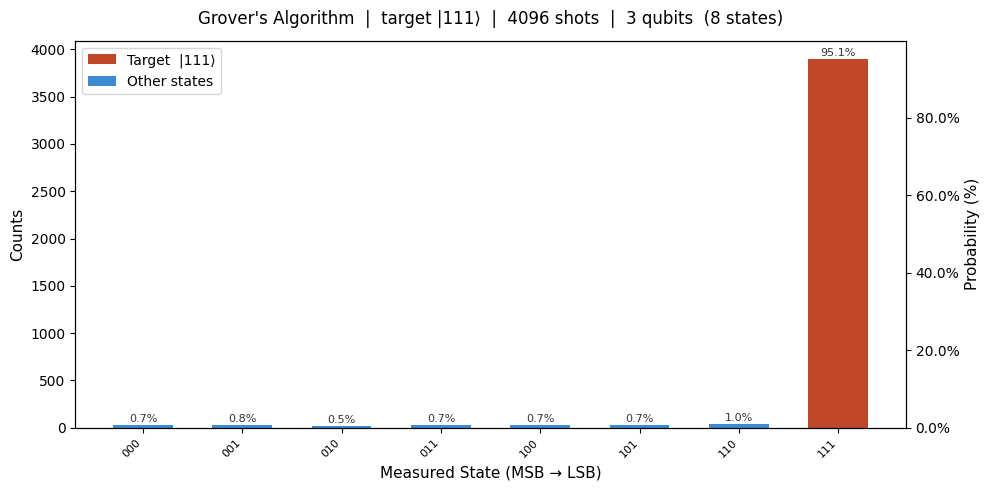

In [ ]:
main()

In [ ]:
import csv
import math
import os
import sys


# ── classical utilities ────────────────────────────────────────────────────────

def is_prime(n: int) -> bool:
    """Basic primality test."""
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.isqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True


def prime_power_base(n: int) -> int | None:
    """
    If n = p^k for some prime p and k >= 2, return p. Otherwise return None.
    """
    for k in range(2, int(math.log2(n)) + 1):
        root = round(n ** (1 / k))
        for candidate in [root - 1, root, root + 1]:
            if candidate >= 2 and candidate ** k == n and is_prime(candidate):
                return candidate
    return None


def classical_period(a: int, N: int) -> int:
    """Brute-force period of a^x mod N (for pre-check / small N verification)."""
    r, val = 1, a % N
    while val != 1:
        val = (val * a) % N
        r  += 1
        if r > N:
            return -1        # should not happen for valid a
    return r


# ── input helpers ──────────────────────────────────────────────────────────────

def get_N() -> int:
    print("\nEnter N — the number you want to factor.")
    print("  • Must be a positive odd composite integer.")
    print("  • Recommended range for simulation: 15 ≤ N ≤ 63")
    print("  • Example: 15, 21, 35\n")
    while True:
        raw = input("N: ").strip()
        if not raw.isdigit():
            print("  ✗  Please enter a positive integer.")
            continue
        n = int(raw)
        if n < 4:
            print("  ✗  N must be at least 4.")
            continue
        return n


def get_a(N: int) -> int:
    print(f"\nEnter k — the base for period finding.")
    print(f"  • Must satisfy 1 < k < {N}")
    print(f"  • GCD(k, N) must equal 1 (coprime)")
    print(f"  • Recommended choices for N={N}: ", end="")
    suggestions = [x for x in range(2, N) if math.gcd(x, N) == 1][:N-2]
    print(", ".join(map(str, suggestions)))
    print()
    while True:
        raw = input("k: ").strip()
        if not raw.isdigit():
            print("  ✗  Please enter a positive integer.")
            continue
        a = int(raw)
        if a <= 1 or a >= N:
            print(f"  ✗  a must satisfy 1 < a < {N}.")
            continue
        return a


# ── main ───────────────────────────────────────────────────────────────────────

def main():
    print("=" * 56)
    print("  Shor's Algorithm — Input Configuration")
    print("=" * 56)

    N = get_N()

    # ── Classical pre-checks ───────────────────────────────────────────────────
    print(f"\n── Classical Pre-checks for N = {N} ──────────────────────")

    # Check 1: even
    if N % 2 == 0:
        print(f"  ⚡ N = {N} is even.")
        print(f"     Trivial factor found: 2 × {N // 2} = {N}")
        print("     No quantum circuit needed.")
        return   # ❗ changed from sys.exit()

    # Check 2: prime
    if is_prime(N):
        print(f"  ⚡ N = {N} is prime — nothing to factor.")
        return   # ❗ safer than sys.exit()

    # Check 3: prime power
    base = prime_power_base(N)
    if base is not None:
        k = round(math.log(N) / math.log(base))
        print(f"  ⚡ N = {N} = {base}^{k} — prime power.")
        print(f"     Factor: {base}")
        return

    print(f"  ✓  N = {N} is a valid composite — proceeding to quantum phase.")

    # ── Get a ──────────────────────────────────────────────────────────────────
    a = get_a(N)

    # Check 4: GCD(a, N)
    g = math.gcd(a, N)
    if g != 1:
        print(f"\n  ⚡ GCD({a}, {N}) = {g} — non-trivial factor found!")
        print(f"     {N} = {g} × {N // g}")
        return

    print(f"  ✓  GCD({a}, {N}) = 1 — valid base, proceeding.")

    # ── Qubit counts ───────────────────────────────────────────────────────────
    n_target = math.ceil(math.log2(N))
    n_count = 2 * n_target

    # ── Summary ────────────────────────────────────────────────────────────────
    print(f"\n── Summary ───────────────────────────────────────────────")
    print(f"  N               : {N}")
    print(f"  a               : {a}")
    print(f"  n_target qubits : {n_target}")
    print(f"  n_count  qubits : {n_count}")
    print(f"  Total qubits    : {n_count + n_target}")
    print(f"  Function        : f(x) = {a}^x mod {N}")
    print("─" * 56)

    # ── Safe output path (FIXED) ───────────────────────────────────────────────
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()   # ✅ fallback for notebooks/IDEs

    out_path = os.path.join(base_dir, "shor_input.csv")

    # ── Write CSV ──────────────────────────────────────────────────────────────
    try:
        with open(out_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["N", "a", "n_count", "n_target"])
            writer.writerow([N, a, n_count, n_target])

        print(f"\n  ✓  Saved to : {out_path}")

    except Exception as e:
        print(f"\n  ✗  Failed to save CSV: {e}")
        return

    print("  Run shor_quantum.py to build and simulate the circuit.\n")

In [ ]:
main()

  Shor's Algorithm — Input Configuration

Enter N — the number you want to factor.
  • Must be a positive odd composite integer.
  • Recommended range for simulation: 15 ≤ N ≤ 63
  • Example: 15, 21, 35

N: 21

── Classical Pre-checks for N = 21 ──────────────────────
  ✓  N = 21 is a valid composite — proceeding to quantum phase.

Enter k — the base for period finding.
  • Must satisfy 1 < k < 21
  • GCD(k, N) must equal 1 (coprime)
  • Recommended choices for N=21: 2, 4, 5, 8, 10, 11, 13, 16, 17, 19, 20

k: 11
  ✓  GCD(11, 21) = 1 — valid base, proceeding.

── Summary ───────────────────────────────────────────────
  N               : 21
  a               : 11
  n_target qubits : 5
  n_count  qubits : 10
  Total qubits    : 15
  Function        : f(x) = 11^x mod 21
────────────────────────────────────────────────────────

  ✓  Saved to : /content/shor_input.csv
  Run shor_quantum.py to build and simulate the circuit.



In [ ]:
import csv
import math
import os
import sys

import numpy as np

try:
    from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
    from qiskit.circuit.library import QFT
    from qiskit.circuit.library import UnitaryGate
    from qiskit_aer import AerSimulator
    import matplotlib.pyplot as plt
except ImportError as exc:
    sys.exit(
        f"Import error: {exc}\n"
        "Install with:  pip install qiskit qiskit-aer matplotlib numpy"
    )


# ══════════════════════════════════════════════════════════════════════════════
#  CSV reader
# ══════════════════════════════════════════════════════════════════════════════

def read_input(csv_path: str) -> tuple[int, int, int, int]:
    """Parse shor_input.csv → (N, a, n_count, n_target)."""
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  shor_input_gen.py  first."
        )
    with open(csv_path, newline="") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        sys.exit("  ✗  CSV is empty. Re-run shor_input_gen.py.")

    row = rows[0]
    try:
        N        = int(row["N"].strip())
        a        = int(row["a"].strip())
        n_count  = int(row["n_count"].strip())
        n_target = int(row["n_target"].strip())
    except (KeyError, ValueError) as e:
        sys.exit(f"  ✗  Bad CSV format: {e}")

    return N, a, n_count, n_target


# ══════════════════════════════════════════════════════════════════════════════
#  Modular exponentiation unitary
# ══════════════════════════════════════════════════════════════════════════════

def mod_exp_unitary(a: int, power: int, N: int, n_target: int) -> np.ndarray:
    """
    Build the 2^n_target × 2^n_target unitary matrix for the map:
        |y⟩  →  |y · a^power mod N⟩    for y in [0, N-1]
        |y⟩  →  |y⟩                    for y in [N, 2^n_target - 1]

    States y ≥ N are mapped to themselves (they are outside the mod-N domain
    and must be handled to keep the matrix unitary).
    """
    dim  = 2 ** n_target
    U    = np.zeros((dim, dim), dtype=complex)
    mult = pow(int(a), int(power), int(N))   # a^power mod N

    for y in range(dim):
        if y < N:
            image = (y * mult) % N
        else:
            image = y                         # identity on out-of-range states
        U[image][y] = 1.0

    return U


def controlled_mod_exp(a: int, N: int, n_count: int, n_target: int) -> QuantumCircuit:
    """
    Build the full controlled modular exponentiation block.

    For each counting qubit j (0 … n_count-1), apply the gate:
        controlled-U^(2^j)  where U|y⟩ = |a·y mod N⟩

    The j-th counting qubit controls U^(2^j) on the target register.
    Together these implement the map:
        |x⟩|1⟩  →  |x⟩|a^x mod N⟩
    """
    qr_count  = QuantumRegister(n_count,  "count")
    qr_target = QuantumRegister(n_target, "target")
    qc        = QuantumCircuit(qr_count, qr_target, name="ModExp")

    for j in range(n_count):
        power   = 2 ** j
        U_mat   = mod_exp_unitary(a, power, N, n_target)
        U_gate  = UnitaryGate(U_mat, label=f"U^{power}").control(1)
        # control qubit = count[j], target qubits = target[0..n_target-1]
        qc.append(U_gate, [qr_count[j]] + list(qr_target))

    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  Full Shor circuit
# ══════════════════════════════════════════════════════════════════════════════

def build_shor_circuit(N: int, a: int, n_count: int, n_target: int) -> QuantumCircuit:
    """
    Assemble the full Shor period-finding circuit:

        |0⟩^n_count   →  H^n_count  ─────────────────┐
                                                       ├─ measure counting reg
        |0⟩^n_target  →  X[0]  →  ModExp  →  IQFT ──┘

    Step by step:
      1. H on all counting qubits  (uniform superposition over 0…2^n_count - 1)
      2. X on target[0]            (initialise target register to |1⟩)
      3. Controlled modular exp    (entangles counting and target registers)
      4. Inverse QFT on counting   (extracts period as a phase)
      5. Measure counting register
    """
    qr_count  = QuantumRegister(n_count,  "count")
    qr_target = QuantumRegister(n_target, "target")
    cr        = ClassicalRegister(n_count, "c")
    qc        = QuantumCircuit(qr_count, qr_target, cr)

    # Step 1: superposition on counting register
    qc.h(qr_count)
    qc.barrier(label="superposition")

    # Step 2: target register → |1⟩
    qc.x(qr_target[0])
    qc.barrier(label="|1⟩ init")

    # Step 3: controlled modular exponentiation
    mod_exp = controlled_mod_exp(a, N, n_count, n_target)
    qc.append(mod_exp, list(qr_count) + list(qr_target))
    qc.barrier(label="mod exp")

    # Step 4: inverse QFT on counting register
    iqft = QFT(n_count, inverse=True, do_swaps=True, name="IQFT")
    qc.append(iqft, qr_count)
    qc.barrier(label="IQFT")

    # Step 5: measure counting register
    qc.measure(qr_count, cr)

    return qc


# ══════════════════════════════════════════════════════════════════════════════
#  Simulation
# ══════════════════════════════════════════════════════════════════════════════

SHOTS = 2048


def simulate(qc: QuantumCircuit) -> dict:
    sim        = AerSimulator()
    transpiled = transpile(qc, sim, optimization_level=1)
    return sim.run(transpiled, shots=SHOTS).result().get_counts(transpiled)


# ══════════════════════════════════════════════════════════════════════════════
#  Reporting
# ══════════════════════════════════════════════════════════════════════════════

def print_counts(counts: dict, n_count: int) -> None:
    total         = sum(counts.values())
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

    print("\n── Raw Measurement Results (counting register) ──────────────")
    print(f"  {'Bitstring':<20}  {'Phase (dec)':<14}  {'Counts':>6}  {'Prob':>7}")
    print("  " + "─" * 52)

    for bits, count in sorted_counts[:12]:
        phase_int = int(bits, 2)
        phase_frac = phase_int / (2 ** n_count)
        print(f"  {bits:<20}  {phase_frac:<14.6f}  {count:>6}  {count/total*100:>5.1f}%")

    if len(sorted_counts) > 12:
        print(f"  … ({len(sorted_counts) - 12} more low-probability states)")
    print()


def plot_counts(counts: dict, N: int, a: int, n_count: int) -> None:
    total  = sum(counts.values())
    # Convert bitstrings to decimal phase integers for x-axis
    phases = {int(k, 2): v for k, v in counts.items()}
    phases = dict(sorted(phases.items()))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(
        [str(k) for k in phases.keys()],
        phases.values(),
        color="#534AB7",
        edgecolor="none",
        width=0.8,
    )
    ax.set_xlabel(f"Measured phase value (0 … {2**n_count - 1})", fontsize=11)
    ax.set_ylabel("Counts", fontsize=11)
    ax.set_title(
        f"Shor's Algorithm  |  N={N}, a={a}  |  {SHOTS} shots",
        fontsize=12, pad=10,
    )
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    plt.tight_layout()
    plt.savefig("shor_results.png", dpi=150)
    print("  ✓  Histogram saved  : shor_results.png")
    plt.show()


def write_output_csv(counts: dict, n_count: int, out_path: str) -> None:
    """
    Write raw phase samples to shor_output.csv for classical post-processing.
    Each row is one measured bitstring with its decimal phase value and count.
    """
    total = sum(counts.values())
    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["bitstring", "phase_int", "phase_frac", "counts", "n_count"])
        for bits, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
            phase_int  = int(bits, 2)
            phase_frac = phase_int / (2 ** n_count)
            writer.writerow([bits, phase_int, f"{phase_frac:.8f}", count, n_count])
    print(f"  ✓  Phase samples saved : {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    # ── Safe base directory (FIXED) ───────────────────────────────────────────
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()   # fallback for notebooks / IDEs

    csv_in  = os.path.join(base_dir, "shor_input.csv")
    csv_out = os.path.join(base_dir, "shor_output.csv")

    # ── Read input safely ─────────────────────────────────────────────────────
    try:
        N, a, n_count, n_target = read_input(csv_in)
    except Exception as e:
        print(f"\n  ✗ Failed to read input CSV: {e}")
        return

    print("=" * 60)
    print("  Shor's Algorithm — Quantum Period Finding")
    print("=" * 60)
    print(f"  N               : {N}")
    print(f"  a               : {a}")
    print(f"  Function        : f(x) = {a}^x mod {N}")
    print(f"  Counting qubits : {n_count}")
    print(f"  Target qubits   : {n_target}")
    print(f"  Total qubits    : {n_count + n_target}")
    print(f"  Shots           : {SHOTS}")
    print("=" * 60)

    # ⚠️ WARNING for large circuits
    if n_count + n_target > 12:
        print("\n  ⚠️ Warning: Circuit is large — simulation may be VERY slow or fail.")

    # ── Build circuit ─────────────────────────────────────────────────────────
    print("\nBuilding Shor circuit …")
    try:
        qc = build_shor_circuit(N, a, n_count, n_target)
    except Exception as e:
        print(f"  ✗ Circuit build failed: {e}")
        return

    # ── Print circuit ─────────────────────────────────────────────────────────
    print("\n── Circuit (text, decomposed) ──────────────────────────────")
    try:
        print(qc.decompose(reps=1).draw(output="text", fold=120))
    except Exception as e:
        print(f"  (Text draw skipped: {e})")

    # ── Save circuit image ────────────────────────────────────────────────────
    try:
        fig = qc.decompose(reps=1).draw(output="mpl", fold=25, style="bw")
        fig.savefig(os.path.join(base_dir, "shor_circuit.png"), dpi=150, bbox_inches="tight")
        print("  ✓ Circuit diagram saved : shor_circuit.png")
        plt.close(fig)  # ✅ prevents blocking
    except Exception as exc:
        print(f"  (Matplotlib diagram skipped: {exc})")

    # ── Simulation ────────────────────────────────────────────────────────────
    print(f"\nRunning simulation ({SHOTS} shots) on AerSimulator …")

    try:
        counts = simulate(qc)
    except Exception as e:
        print(f"  ✗ Simulation failed: {e}")
        return

    # ── Results ───────────────────────────────────────────────────────────────
    try:
        print_counts(counts, n_count)
    except Exception as e:
        print(f"  (Print counts failed: {e})")

    try:
        write_output_csv(counts, n_count, csv_out)
    except Exception as e:
        print(f"  ✗ Failed to write output CSV: {e}")

    try:
        plot_counts(counts, N, a, n_count)
    except Exception as e:
        print(f"  (Plot skipped: {e})")

    # ── Classical verification ────────────────────────────────────────────────
    print("── Period (classical verification) ─────────────────────────")

    try:
        r_classical, val = 1, a % N
        while val != 1 and r_classical <= N:
            val = (val * a) % N
            r_classical += 1

        if val == 1:
            print(f"  Periodicity     : p = {r_classical}")
            print(f"                     ({a}^{r_classical} mod {N} = 1)")
        else:
            print(f"  Could not find period for a={a}, N={N}")

    except Exception as e:
        print(f"  (Classical verification failed: {e})")

    print("\n  ✓ Done.")
    print("  Run shor_classical_post.py to extract factors.\n")

  Shor's Algorithm — Quantum Period Finding
  N               : 21
  a               : 11
  Function        : f(x) = 11^x mod 21
  Counting qubits : 10
  Target qubits   : 5
  Total qubits    : 15
  Shots           : 2048

  ⚠️ Warning: Circuit is large — simulation may be VERY slow or fail.

Building Shor circuit …


/tmp/ipykernel_9191/2112287361.py:139: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(n_count, inverse=True, do_swaps=True, name="IQFT")



── Circuit (text, decomposed) ──────────────────────────────
          ┌────────────┐ superposition              |1⟩ init                                                   »
 count_0: ┤ U(π/2,0,π) ├───────░───────────────────────░────────■──────────────────────────────────────────────»
          ├────────────┤       ░                       ░        │                                              »
 count_1: ┤ U(π/2,0,π) ├───────░───────────────────────░────────┼───────■──────────────────────────────────────»
          ├────────────┤       ░                       ░        │       │                                      »
 count_2: ┤ U(π/2,0,π) ├───────░───────────────────────░────────┼───────┼───────■──────────────────────────────»
          ├────────────┤       ░                       ░        │       │       │                              »
 count_3: ┤ U(π/2,0,π) ├───────░───────────────────────░────────┼───────┼───────┼───────■──────────────────────»
          ├────────────┤       ░  

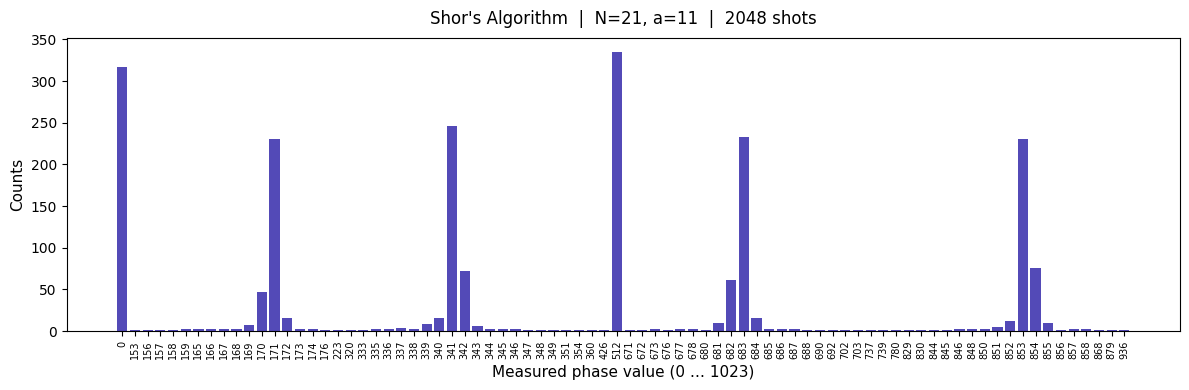

── Period (classical verification) ─────────────────────────
  Periodicity     : p = 6
                     (11^6 mod 21 = 1)

  ✓ Done.
  Run shor_classical_post.py to extract factors.



In [ ]:
main()

In [ ]:
import csv
import math
import os
import sys
from fractions import Fraction


# ══════════════════════════════════════════════════════════════════════════════
#  CSV readers
# ══════════════════════════════════════════════════════════════════════════════

def read_quantum_output(csv_path: str) -> list[tuple[int, float, int, int]]:
    """
    Parse shor_output.csv.
    Returns list of (phase_int, phase_frac, counts, n_count) sorted by counts desc.
    """
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  shor_quantum.py  first."
        )
    rows = []
    with open(csv_path, newline="") as f:
        for row in csv.DictReader(f):
            rows.append((
                int(row["phase_int"]),
                float(row["phase_frac"]),
                int(row["counts"]),
                int(row["n_count"]),
            ))
    if not rows:
        sys.exit("  ✗  shor_output.csv is empty. Re-run shor_quantum.py.")
    return rows


def read_input_config(csv_path: str) -> tuple[int, int]:
    """Parse shor_input.csv → (N, a)."""
    if not os.path.exists(csv_path):
        sys.exit(
            f"  ✗  '{csv_path}' not found.\n"
            "     Run  shor_input_gen.py  first."
        )
    with open(csv_path, newline="") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        sys.exit("  ✗  shor_input.csv is empty.")
    return int(rows[0]["N"]), int(rows[0]["a"])


# ══════════════════════════════════════════════════════════════════════════════
#  Continued fractions — phase → period candidate
# ══════════════════════════════════════════════════════════════════════════════

def phase_to_period_candidates(phase_frac: float, n_count: int, N: int) -> list[int]:
    """
    Convert a measured phase fraction to period candidates using continued fractions.

    The QFT produces a phase ≈ s/r for some integer s.
    Continued fraction expansion of phase_frac finds rational approximations s/r
    with denominator r ≤ N.  Each denominator is a candidate for the period.

    Returns a list of unique candidate r values.
    """
    if phase_frac == 0.0:
        return []                       # phase 0 carries no period information

    candidates = []
    # Use Python's Fraction with a limited denominator to get convergents
    frac = Fraction(phase_frac).limit_denominator(N)

    # Collect the denominator and its small multiples (in case r = k·denom)
    r = frac.denominator
    for multiplier in range(1, 5):
        candidate = r * multiplier
        if candidate <= N and candidate not in candidates:
            candidates.append(candidate)

    return candidates


# ══════════════════════════════════════════════════════════════════════════════
#  Period validation
# ══════════════════════════════════════════════════════════════════════════════

def validate_period(r: int, a: int, N: int) -> tuple[bool, str]:
    """
    Check that r is a valid period for a^x mod N:
      1. r > 0
      2. a^r mod N == 1              (r is actually a period)
      3. r is even                   (needed for factor extraction)
      4. a^(r/2) mod N ≠ N-1        (not the trivial ±1 case)
    Returns (valid: bool, reason: str).
    """
    if r <= 0:
        return False, "r ≤ 0"
    if pow(a, r, N) != 1:
        return False, f"a^r mod N = {pow(a, r, N)} ≠ 1"
    if r % 2 != 0:
        return False, "r is odd"
    half = pow(a, r // 2, N)
    if half == N - 1:
        return False, f"a^(r/2) mod N = {half} = N-1 (trivial)"
    return True, "ok"


# ══════════════════════════════════════════════════════════════════════════════
#  Factor extraction
# ══════════════════════════════════════════════════════════════════════════════

def extract_factors(r: int, a: int, N: int) -> tuple[int, int] | None:
    """
    Given a valid period r, compute:
        m1 = GCD(a^(r/2) - 1, N)
        m2 = GCD(a^(r/2) + 1, N)
    Return (m1, m2) if both are non-trivial (1 < m1,m2 < N), else None.
    """
    half  = pow(a, r // 2, N)
    m1    = math.gcd(half - 1, N)
    m2    = math.gcd(half + 1, N)

    if 1 < m1 < N:
        return m1, N // m1
    if 1 < m2 < N:
        return m2, N // m2
    return None


# ══════════════════════════════════════════════════════════════════════════════
#  Entry point
# ══════════════════════════════════════════════════════════════════════════════

def main():
    # ── Safe base directory (FIXED) ───────────────────────────────────────────
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()   # fallback for notebooks / IDEs

    input_csv  = os.path.join(base_dir, "shor_input.csv")
    output_csv = os.path.join(base_dir, "shor_output.csv")

    # ── Read inputs safely ────────────────────────────────────────────────────
    try:
        N, a = read_input_config(input_csv)
    except Exception as e:
        print(f"\n  ✗ Failed to read input config: {e}")
        return

    try:
        phase_rows = read_quantum_output(output_csv)
    except Exception as e:
        print(f"\n  ✗ Failed to read quantum output: {e}")
        return

    if not phase_rows:
        print("\n  ✗ No phase data found.")
        return

    n_count     = phase_rows[0][3]
    total_shots = sum(r[2] for r in phase_rows)

    print("=" * 60)
    print("  Shor's Algorithm — Classical Post-Processing")
    print("=" * 60)
    print(f"  N               : {N}")
    print(f"  k               : {a}")
    print(f"  Function        : f(x) = {a}^x mod {N}")
    print(f"  n_count         : {n_count} qubits  →  {2**n_count} phase slots")
    print(f"  Phase samples   : {len(phase_rows)} distinct values ({total_shots} total shots)")
    print("=" * 60)

    # ── Continued fractions analysis ──────────────────────────────────────────
    print("\n── Continued Fraction Analysis ─────────────────────────────")
    print(f"  {'Phase frac':<14}  {'Candidate r':<14}  {'Valid?':<8}  Reason")
    print("  " + "─" * 54)

    found_factors = None
    seen_r        = set()

    # Try highest-probability phases first
    for phase_int, phase_frac, counts, _ in phase_rows:

        if phase_int == 0:
            print(f"  {phase_frac:<14.6f}  {'—':<14}  {'skip':<8}  Phase = 0")
            continue

        candidates = phase_to_period_candidates(phase_frac, n_count, N)

        if not candidates:
            continue

        for r in candidates:
            if r in seen_r:
                continue
            seen_r.add(r)

            try:
                valid, reason = validate_period(r, a, N)
            except Exception as e:
                print(f"  {phase_frac:<14.6f}  r = {r:<10}  ERR      {e}")
                continue

            prob_str = f"{counts/total_shots*100:.1f}%"
            print(f"  {phase_frac:<14.6f}  r = {r:<10}  {'✓' if valid else '✗':<8}  {reason}  [{prob_str}]")

            if valid and found_factors is None:
                try:
                    factors = extract_factors(r, a, N)
                except Exception as e:
                    print(f"  (Factor extraction failed: {e})")
                    continue

                if factors:
                    found_factors = (r, factors[0], factors[1])

        if found_factors:
            break

    # ── Final result ──────────────────────────────────────────────────────────
    print("\n── Result ──────────────────────────────────────────────────")

    if found_factors:
        r, m1, m2 = found_factors

        try:
            raw_half = a ** (r // 2)
        except OverflowError:
            raw_half = "too large to display"

        print(f"  Period found    : r = {r}")
        print(f"  a^(r/2) mod N  : {pow(a, r//2, N)}")

        if isinstance(raw_half, int):
            print(f"  a^(r/2)        : {a}^{r//2} = {raw_half}")
            print(f"  a^(r/2) - 1    : {raw_half - 1}")
            print(f"  a^(r/2) + 1    : {raw_half + 1}")

        print("\n  ✓ FACTORS FOUND")
        print(f"  N1 = {m1}, N2 = {m2}")

        # Verification
        if m1 * m2 == N:
            print(f"\n  Verification   : {m1} × {m2} = {N} ✓")
        else:
            print(f"\n  Verification   : {m1} × {m2} ≠ {N} ✗")

    else:
        print("  ✗ No valid period found.")
        print("    This is NORMAL due to quantum randomness.")
        print("    → Re-run shor_quantum.py and try again.")

    print("\n  ✓ Done.\n")

In [ ]:
main()

  Shor's Algorithm — Classical Post-Processing
  N               : 21
  k               : 11
  Function        : f(x) = 11^x mod 21
  n_count         : 10 qubits  →  1024 phase slots
  Phase samples   : 80 distinct values (2048 total shots)

── Continued Fraction Analysis ─────────────────────────────
  Phase frac      Candidate r     Valid?    Reason
  ──────────────────────────────────────────────────────
  0.500000        r = 2           ✗         a^r mod N = 16 ≠ 1  [16.4%]
  0.500000        r = 4           ✗         a^r mod N = 4 ≠ 1  [16.4%]
  0.500000        r = 6           ✓         ok  [16.4%]
  0.500000        r = 8           ✗         a^r mod N = 16 ≠ 1  [16.4%]

── Result ──────────────────────────────────────────────────
  Period found    : r = 6
  a^(r/2) mod N  : 8
  a^(r/2)        : 11^3 = 1331
  a^(r/2) - 1    : 1330
  a^(r/2) + 1    : 1332

  ✓ FACTORS FOUND
  N1 = 7, N2 = 3

  Verification   : 7 × 3 = 21 ✓

  ✓ Done.

